<a href="https://colab.research.google.com/github/ys5591/Yunsu-Shin/blob/main/Normative_Modeling_Practice_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import re
from pathlib import Path
import os
from google.colab import files

print("Current directory:", os.getcwd())
print("Files before upload:")
print(os.listdir("."))

uploaded = files.upload()

csv_files = list(Path(".").glob("*4RUNS*.csv"))

print("Found CSV files:")
print(csv_files)

if len(csv_files) == 0:
    raise FileNotFoundError("4RUNS csv file was not found. Please upload the 4RUNS csv file.")

file_path = csv_files[0]
df = pd.read_csv(file_path)

print("Loaded file:", file_path)
print("Dataset shape:", df.shape)
df.head()

Current directory: /content
Files before upload:
['.config', 'Combined T maze recording.xlsx', 'WM_data_4RUNS_processed.csv', 'drive', 'sample_data']


Saving Combined_T_maze_recording_4RUNS.csv to Combined_T_maze_recording_4RUNS.csv
Found CSV files:
[PosixPath('Combined_T_maze_recording_4RUNS.csv'), PosixPath('WM_data_4RUNS_processed.csv')]
Loaded file: Combined_T_maze_recording_4RUNS.csv
Dataset shape: (12150, 13)


,BlockIndex,MouseID,TestingLabel,TestingSession,Date,Delay_s,DelayFromLabel_s,Trial,Order,Choice,TrialCorrect_DNMS,Correct_cumulative_original,Correct_cumulative_recomputed_DNMS
0,1,Sd43,Testing1-10,1,2025-08-18,10,10,0,left,right,1.0,1,1
1,1,Sd43,Testing1-10,1,2025-08-18,10,10,1,right,left,1.0,2,2
2,1,Sd43,Testing1-10,1,2025-08-18,10,10,2,left,left,0.0,2,2
3,1,Sd43,Testing1-10,1,2025-08-18,10,10,3,left,right,1.0,3,3
4,1,Sd43,Testing1-10,1,2025-08-18,10,10,4,right,left,1.0,4,4


In [ ]:
# ============================================================
# STEP 1.1 DATA SELECTION
# For INT HCPYA 4RUNS data
# ============================================================

# 1. Define subject ID
subject_id = "subject_id"

print("Subject ID:", subject_id)
print("Number of subjects:", df[subject_id].nunique())
print("Duplicated subject IDs:", df[subject_id].duplicated().sum())

Subject ID: subject_id


KeyError: 'subject_id'

In [ ]:
# 1-2. Define covariates

covariates = [
    "Age",
    "Avg_Mean_FD_included",
    "Avg_Percent_Excluded"
]

print("Covariates:", covariates)
print(df[covariates].describe())

Covariates: ['Age', 'Avg_Mean_FD_included', 'Avg_Percent_Excluded']
              Age  Avg_Mean_FD_included  Avg_Percent_Excluded
count  973.000000            973.000000            973.000000
mean    28.705036              0.110838              0.072717
std      3.697728              0.024641              0.068504
min     22.000000              0.056715              0.000000
25%     26.000000              0.093015              0.020833
50%     29.000000              0.109305              0.050833
75%     32.000000              0.128035              0.107083
max     36.000000              0.185604              0.376250


In [ ]:
# 1-3. Define batch effects

batch_effects = ["Sex"]

print("Batch effects:", batch_effects)
print(df["Sex"].value_counts(dropna=False))

Batch effects: ['Sex']
Sex
F    524
M    449
Name: count, dtype: int64


In [ ]:
# 1-4. Define response variables

response_variables = [
    col for col in df.columns
    if re.match(r"^Region_\d+$", col)
]

print("Number of response variables before filtering:", len(response_variables))
print("First 10 response variables:", response_variables[:10])

Number of response variables before filtering: 187
First 10 response variables: ['Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region_6', 'Region_7', 'Region_8', 'Region_9', 'Region_10']


In [ ]:
# 1-5. Remove response variables with zero variance

response_variables = [
    col for col in response_variables
    if df[col].var(skipna=True) > 0
]

print("Number of response variables after filtering:", len(response_variables))

Number of response variables after filtering: 187


In [ ]:
# 1-6. Check missing values

selected_columns = [subject_id] + covariates + batch_effects + response_variables

missing_summary = df[selected_columns].isna().sum()
missing_summary = missing_summary[missing_summary > 0]

print("Variables with missing values:")
print(missing_summary)

print("Total missing values:", df[selected_columns].isna().sum().sum())

Variables with missing values:
Series([], dtype: int64)
Total missing values: 0


In [ ]:
# 1-7. Check covariate correlations

print("Covariate correlations:")
print(df[covariates].corr())

Covariate correlations:
                           Age  Avg_Mean_FD_included  Avg_Percent_Excluded
Age                   1.000000              0.032413              0.027160
Avg_Mean_FD_included  0.032413              1.000000              0.829473
Avg_Percent_Excluded  0.027160              0.829473              1.000000


In [ ]:
# 1-8. Save selected dataset for Step 1.2

df_selected = df[selected_columns].copy()

output_file = "step1_selected_INT_HCPYA_4RUNS.csv"
df_selected.to_csv(output_file, index=False)

print("Saved:", output_file)
print("Final selected data shape:", df_selected.shape)

print("\nFinal setup:")
print("Subject ID:", subject_id)
print("Covariates:", covariates)
print("Batch effects:", batch_effects)
print("Number of response variables:", len(response_variables))

Saved: step1_selected_INT_HCPYA_4RUNS.csv
Final selected data shape: (973, 192)

Final setup:
Subject ID: subject_id
Covariates: ['Age', 'Avg_Mean_FD_included', 'Avg_Percent_Excluded']
Batch effects: ['Sex']
Number of response variables: 187


In [ ]:
# ============================================================
# STEP 1.2 DATA PREPARATION
# Install and verify PCNtoolkit
# ============================================================

!pip install pcntoolkit

In [ ]:
import pcntoolkit
print("PCNtoolkit version:", pcntoolkit.__version__)

/usr/local/lib/python3.12/dist-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


PCNtoolkit version: 1.2.0.post1


In [ ]:
#1-2.1) Loading data

import pandas as pd
import numpy as np
import re
from pcntoolkit import NormData

df_nm = pd.read_csv("step1_selected_INT_HCPYA_4RUNS.csv")

print("Loaded selected dataset:", df_nm.shape)
df_nm.head()

Loaded selected dataset: (973, 192)


,subject_id,Age,Avg_Mean_FD_included,Avg_Percent_Excluded,Sex,Region_1,Region_2,Region_3,Region_4,Region_5,...,Region_178,Region_179,Region_180,Region_181,Region_182,Region_183,Region_184,Region_185,Region_186,Region_187
0,1,27,0.087265,0.014375,M,2.559105,2.617193,2.620055,2.675553,2.761913,...,2.585995,2.582101,2.630313,2.457615,2.435188,2.460994,2.450168,2.444210,2.438977,2.400383
1,2,27,0.084923,0.009167,F,2.580930,2.698916,2.582031,2.621526,2.705428,...,2.361969,2.617795,2.588164,2.408751,2.407111,2.503539,2.463368,2.449589,2.426703,2.438109
2,3,33,0.135897,0.097083,M,2.836223,3.035263,3.022696,3.030292,3.091255,...,2.560341,2.837626,2.812529,2.600862,2.530387,2.936005,2.604523,2.549520,2.538336,2.505538
3,4,27,0.121519,0.039583,M,2.632935,2.706086,2.719773,2.745197,2.918664,...,2.442763,2.630285,2.545559,2.408486,2.406403,2.429504,2.423994,2.408040,2.437052,2.400483
4,5,35,0.127168,0.067708,F,2.785657,2.870716,2.765683,2.801378,2.989401,...,2.535067,2.624556,2.530562,2.421422,2.439154,2.422066,2.436732,2.407120,2.414961,2.408615


In [ ]:
#1-2.2. Define variables again

subject_id = "subject_id"

# Primary model: use Age + one motion covariate
covariates = [
    "Age",
    "Avg_Mean_FD_included"
]

batch_effects = [
    "Sex"
]

response_variables = [
    col for col in df_nm.columns
    if re.match(r"^Region_\d+$", col)
]

print("Subject ID:", subject_id)
print("Covariates:", covariates)
print("Batch effects:", batch_effects)
print("Number of response variables:", len(response_variables))

Subject ID: subject_id
Covariates: ['Age', 'Avg_Mean_FD_included']
Batch effects: ['Sex']
Number of response variables: 187


In [ ]:
#1-2.3. Preprocessing checks

# ------------------------------------------------------------
# Preprocessing checks
# ------------------------------------------------------------

selected_columns = [subject_id] + covariates + batch_effects + response_variables

# Keep only selected columns
df_prep = df_nm[selected_columns].copy()

# Check missing values
print("Total missing values:", df_prep.isna().sum().sum())

# Check infinite values in numeric columns
numeric_cols = covariates + response_variables
inf_count = np.isinf(df_prep[numeric_cols].to_numpy()).sum()
print("Total infinite values:", inf_count)

# Replace inf with NaN if any exist
df_prep[numeric_cols] = df_prep[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Check zero-variance response variables again
zero_var_regions = [
    col for col in response_variables
    if df_prep[col].var(skipna=True) == 0
]

print("Zero-variance regions:", zero_var_regions)

# Remove zero-variance regions if any
response_variables = [
    col for col in response_variables
    if col not in zero_var_regions
]

selected_columns = [subject_id] + covariates + batch_effects + response_variables
df_prep = df_prep[selected_columns].copy()

print("Prepared dataframe shape:", df_prep.shape)

Total missing values: 0
Total infinite values: 0
Zero-variance regions: []
Prepared dataframe shape: (973, 191)


In [ ]:
#1-2.4. Quality control summary

# ------------------------------------------------------------
# Quality control summary
# ------------------------------------------------------------

print("Number of subjects:", df_prep[subject_id].nunique())
print("Duplicated subject IDs:", df_prep[subject_id].duplicated().sum())

print("\nAge summary:")
print(df_prep["Age"].describe())

print("\nSex distribution:")
print(df_prep["Sex"].value_counts(dropna=False))

print("\nCovariate summary:")
print(df_prep[covariates].describe())

print("\nResponse variable summary:")
print(df_prep[response_variables].describe().T[["mean", "std", "min", "max"]].head())

Number of subjects: 973
Duplicated subject IDs: 0

Age summary:
count    973.000000
mean      28.705036
std        3.697728
min       22.000000
25%       26.000000
50%       29.000000
75%       32.000000
max       36.000000
Name: Age, dtype: float64

Sex distribution:
Sex
F    524
M    449
Name: count, dtype: int64

Covariate summary:
              Age  Avg_Mean_FD_included
count  973.000000            973.000000
mean    28.705036              0.110838
std      3.697728              0.024641
min     22.000000              0.056715
25%     26.000000              0.093015
50%     29.000000              0.109305
75%     32.000000              0.128035
max     36.000000              0.185604

Response variable summary:
              mean       std       min       max
Region_1  2.753065  0.175610  2.412688  3.500440
Region_2  2.900235  0.242518  2.418278  4.042323
Region_3  2.845283  0.218384  2.437915  3.801874
Region_4  2.839813  0.194025  2.453341  3.653095
Region_5  2.958808  0.217832  

In [ ]:
# ------------------------------------------------------------
# Optional QC: count extreme feature-wise values
# This does not remove anything yet.
# ------------------------------------------------------------

z_threshold = 10

region_means = df_prep[response_variables].mean(axis=0)
region_stds = df_prep[response_variables].std(axis=0)

z_values = (df_prep[response_variables] - region_means) / region_stds
extreme_mask = z_values.abs() > z_threshold

print("Number of extreme region values |Z| > 10:", extreme_mask.sum().sum())
print("Number of subjects with at least one extreme region:", extreme_mask.any(axis=1).sum())

Number of extreme region values |Z| > 10: 0
Number of subjects with at least one extreme region: 0


In [ ]:
# ============================================================
# STEP 1.2 continued: Create PCNtoolkit NormData object
# ============================================================

from pcntoolkit import NormData

reference_norm_data = NormData.from_dataframe(
    name="INT_HCPYA_4RUNS",
    dataframe=df_prep,
    covariates=covariates,
    batch_effects=batch_effects,
    response_vars=response_variables,
    subject_ids=subject_id,
    remove_Nan=True,
    remove_outliers=True,
    z_threshold=10,
)

print("NormData object created successfully.")
print(reference_norm_data)

Process: 9736 - 2026-05-27 01:56:38 - Removed 0 NANs
Process: 9736 - 2026-05-27 01:56:39 - Removed 0 outliers
Process: 9736 - 2026-05-27 01:56:39 - Dataset "INT_HCPYA_4RUNS" created.
    - 973 observations
    - 973 unique subjects
    - 2 covariates
    - 187 response variables
    - 1 batch effects:
    	Sex (2)
    
NormData object created successfully.
<xarray.NormData> Size: 1MB
Dimensions:            (observations: 973, response_vars: 187, covariates: 2,
                        batch_effect_dims: 1)
Coordinates:
  * observations       (observations) int64 8kB 0 1 2 3 4 ... 969 970 971 972
  * response_vars      (response_vars) <U10 7kB 'Region_1' ... 'Region_187'
  * covariates         (covariates) <U20 160B 'Age' 'Avg_Mean_FD_included'
  * batch_effect_dims  (batch_effect_dims) <U3 12B 'Sex'
Data variables:
    subject_ids        (observations) int64 8kB 1 2 3 4 ... 1073 1074 1075 1077
    Y                  (observations, response_vars) float64 1MB 2.559 ... 2.408
    X        

In [ ]:
# ============================================================
# STEP 1.2 continued: Train-test split
# ============================================================

train, test = reference_norm_data.train_test_split(
    splits=(0.8, 0.2),
    split_names=["train", "test"],
    random_state=42,
)

print("Train-test split completed.")
print("Train object:")
print(train)

print("\nTest object:")
print(test)

Train-test split completed.
Train object:
<xarray.NormData> Size: 1MB
Dimensions:            (observations: 778, response_vars: 187, covariates: 2,
                        batch_effect_dims: 1)
Coordinates:
  * observations       (observations) int64 6kB 847 912 725 414 ... 77 656 967
  * response_vars      (response_vars) <U10 7kB 'Region_1' ... 'Region_187'
  * covariates         (covariates) <U20 160B 'Age' 'Avg_Mean_FD_included'
  * batch_effect_dims  (batch_effect_dims) <U3 12B 'Sex'
Data variables:
    subject_ids        (observations) int64 6kB 940 1011 807 476 ... 91 731 1071
    Y                  (observations, response_vars) float64 1MB 2.895 ... 2.422
    X                  (observations, covariates) float64 12kB 28.0 ... 0.1336
    batch_effects      (observations, batch_effect_dims) <U1 3kB 'M' 'F' ... 'M'
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           train
    unique_batch_effects:      

In [ ]:
# ============================================================
# Optional check: train/test split balance
# ============================================================

print("Original Sex distribution:")
print(df_prep["Sex"].value_counts(normalize=True))

print("\nOriginal age summary:")
print(df_prep["Age"].describe())

Original Sex distribution:
Sex
F    0.538541
M    0.461459
Name: proportion, dtype: float64

Original age summary:
count    973.000000
mean      28.705036
std        3.697728
min       22.000000
25%       26.000000
50%       29.000000
75%       32.000000
max       36.000000
Name: Age, dtype: float64


In [ ]:
import shutil
from pathlib import Path

failed_dir = Path("./out/models/INT_HCPYA_test_HBR_5regions")

if failed_dir.exists():
    shutil.rmtree(failed_dir)
    print("Removed failed output folder:", failed_dir)
else:
    print("No failed folder found.")

Removed failed output folder: out/models/INT_HCPYA_test_HBR_5regions


In [ ]:
# ============================================================
# STEP 1.3 MODELLING - TEST WITH 1 REGION
# Use PyMC sampler instead of nutpie
# ============================================================

from pcntoolkit import NormativeModel, HBR
from pathlib import Path
import shutil

# Select only one response variable first
one_response_var = [str(train.response_vars.values[0])]

train_one = train.sel(response_vars=one_response_var)
test_one = test.sel(response_vars=one_response_var)

print("Testing response variable:", one_response_var)
print("Train one:", train_one)
print("Test one:", test_one)

Testing response variable: ['Region_1']
Train one: <xarray.NormData> Size: 34kB
Dimensions:            (observations: 778, response_vars: 1, covariates: 2,
                        batch_effect_dims: 1)
Coordinates:
  * observations       (observations) int64 6kB 847 912 725 414 ... 77 656 967
  * response_vars      (response_vars) <U10 40B 'Region_1'
  * covariates         (covariates) <U20 160B 'Age' 'Avg_Mean_FD_included'
  * batch_effect_dims  (batch_effect_dims) <U3 12B 'Sex'
Data variables:
    subject_ids        (observations) int64 6kB 940 1011 807 476 ... 91 731 1071
    Y                  (observations, response_vars) float64 6kB 2.895 ... 2.66
    X                  (observations, covariates) float64 12kB 28.0 ... 0.1336
    batch_effects      (observations, batch_effect_dims) <U1 3kB 'M' 'F' ... 'M'
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           train
    unique_batch_effects:           {np.s

In [ ]:
save_dir_one = "./out/models/INT_HCPYA_test_HBR_1region_pymc"

# Remove old folder if it exists
if Path(save_dir_one).exists():
    shutil.rmtree(save_dir_one)

model_one = NormativeModel(
    template_regression_model=HBR(
        nuts_sampler="pymc",
        draws=500,
        tune=250,
        chains=2,
        cores=1,
        progressbar=True
    ),
    save_dir=save_dir_one,
    inscaler="standardize",
    outscaler="standardize",
    name="INT_HCPYA_test_HBR_1region_pymc",
)

print("HBR model created with PyMC sampler.")

HBR model created with PyMC sampler.


In [ ]:
model_one.fit_predict(train_one, test_one)

print("1-region HBR model completed successfully.")

Process: 9736 - 2026-05-27 02:13:10 - Fitting models on 1 response variables.
Process: 9736 - 2026-05-27 02:13:10 - Fitting model for Region_1.


Output()

ERROR:pymc.stats.convergence:There were 20 divergences after tuning. Increase `target_accept` or reparameterize.


Process: 9736 - 2026-05-27 02:14:58 - Saving model to:
	./out/models/INT_HCPYA_test_HBR_1region_pymc.
Process: 9736 - 2026-05-27 02:14:58 - Making predictions on 1 response variables.
Process: 9736 - 2026-05-27 02:14:58 - Computing z-scores for 1 response variables.
Process: 9736 - 2026-05-27 02:14:58 - Computing z-scores for Region_1.
Process: 9736 - 2026-05-27 02:15:02 - Computing centiles for 1 response variables.
Process: 9736 - 2026-05-27 02:15:02 - Computing centiles for Region_1.
Process: 9736 - 2026-05-27 02:15:03 - Computing log-probabilities for 1 response variables.
Process: 9736 - 2026-05-27 02:15:03 - Computing log-probabilities for 1 response variables.
Process: 9736 - 2026-05-27 02:15:03 - Computing log-probabilities for Region_1.
Process: 9736 - 2026-05-27 02:15:06 - Computing yhat for 1 response variables.


/usr/local/lib/python3.12/dist-packages/pcntoolkit/dataio/norm_data.py:1178: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  subject_ids = subject_ids.stack(level="centile")


Process: 9736 - 2026-05-27 02:15:07 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 2 covariates
    - 1 response variables
    - 1 batch effects:
    	Sex (1)
    
Process: 9736 - 2026-05-27 02:15:07 - Computing centiles for 1 response variables.
Process: 9736 - 2026-05-27 02:15:07 - Computing centiles for Region_1.
Process: 9736 - 2026-05-27 02:15:08 - Harmonizing data on 1 response variables.
Process: 9736 - 2026-05-27 02:15:08 - Harmonizing data for Region_1.
Process: 9736 - 2026-05-27 02:15:09 - Making predictions on 1 response variables.
Process: 9736 - 2026-05-27 02:15:09 - Computing z-scores for 1 response variables.
Process: 9736 - 2026-05-27 02:15:09 - Computing z-scores for Region_1.
Process: 9736 - 2026-05-27 02:15:10 - Computing centiles for 1 response variables.
Process: 9736 - 2026-05-27 02:15:10 - Computing centiles for Region_1.
Process: 9736 - 2026-05-27 02:15:11 - Computing log-probabilities for 1 response variables.
Process: 9736 

/usr/local/lib/python3.12/dist-packages/pcntoolkit/dataio/norm_data.py:1178: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  subject_ids = subject_ids.stack(level="centile")


Process: 9736 - 2026-05-27 02:15:12 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 2 covariates
    - 1 response variables
    - 1 batch effects:
    	Sex (1)
    
Process: 9736 - 2026-05-27 02:15:12 - Computing centiles for 1 response variables.
Process: 9736 - 2026-05-27 02:15:12 - Computing centiles for Region_1.
Process: 9736 - 2026-05-27 02:15:14 - Harmonizing data on 1 response variables.
Process: 9736 - 2026-05-27 02:15:14 - Harmonizing data for Region_1.
1-region HBR model completed successfully.


In [ ]:
import os

print("Saved files under:", save_dir_one)

for root, dirs, files in os.walk(save_dir_one):
    level = root.replace(save_dir_one, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for f in files[:10]:
        print(f"{subindent}{f}")

Saved files under: ./out/models/INT_HCPYA_test_HBR_1region_pymc
INT_HCPYA_test_HBR_1region_pymc/
  model/
    normative_model.json
    Region_1/
      regression_model.json
      idata.nc
  plots/
    qq_Region_1_train.png
    centiles_Region_1_train_harmonized.png
    qq_Region_1_test.png
    centiles_Region_1_test_harmonized.png
  results/
    Z_test.csv
    centiles_train.csv
    statistics_test.csv
    logp_train.csv
    statistics_train.csv
    Z_train.csv
    centiles_test.csv
    logp_test.csv


In [ ]:
import pandas as pd
from pathlib import Path

results_dir = Path(save_dir_one) / "results"

z_test_path = results_dir / "Z_test.csv"
stats_test_path = results_dir / "statistics_test.csv"

if z_test_path.exists():
    z_test = pd.read_csv(z_test_path)
    print("Z_test shape:", z_test.shape)
    display(z_test.head())
else:
    print("Z_test.csv not found.")

if stats_test_path.exists():
    stats_test = pd.read_csv(stats_test_path)
    print("statistics_test shape:", stats_test.shape)
    display(stats_test.head())
else:
    print("statistics_test.csv not found.")

Z_test shape: (195, 3)


,observations,subject_ids,Region_1
0,4,5,0.343009
1,16,18,-0.697979
2,17,19,0.144946
3,28,30,0.413498
4,36,40,-0.499290


statistics_test shape: (11, 2)


,statistic,Region_1
0,EXPV,0.103317
1,MACE,0.035897
2,MAPE,0.043192
3,MSLL,-0.042193
4,NLL,1.312460


In [ ]:
import shutil
from pathlib import Path

old_dir = Path("./out/models/INT_HCPYA_test_HBR_1region_pymc_stable")

if old_dir.exists():
    shutil.rmtree(old_dir)
    print("Removed old folder:", old_dir)
else:
    print("No old folder found.")

No old folder found.


In [ ]:
from pcntoolkit import NormativeModel, HBR
from pathlib import Path

one_response_var = [str(train.response_vars.values[0])]

train_one = train.sel(response_vars=one_response_var)
test_one = test.sel(response_vars=one_response_var)

save_dir_one_stable = "./out/models/INT_HCPYA_test_HBR_1region_pymc_stable"

model_one_stable = NormativeModel(
    template_regression_model=HBR(
        nuts_sampler="pymc",
        draws=1000,
        tune=1000,
        chains=4,
        cores=1,
        init="jitter+adapt_diag",
        progressbar=True
    ),
    save_dir=save_dir_one_stable,
    inscaler="standardize",
    outscaler="standardize",
    name="INT_HCPYA_test_HBR_1region_pymc_stable",
)

model_one_stable.fit_predict(train_one, test_one)

print("Stable 1-region HBR model completed.")

Process: 9736 - 2026-05-27 02:18:04 - Fitting models on 1 response variables.
Process: 9736 - 2026-05-27 02:18:04 - Fitting model for Region_1.


Output()

ERROR:pymc.stats.convergence:There were 126 divergences after tuning. Increase `target_accept` or reparameterize.


Process: 9736 - 2026-05-27 02:23:29 - Saving model to:
	./out/models/INT_HCPYA_test_HBR_1region_pymc_stable.
Process: 9736 - 2026-05-27 02:23:29 - Making predictions on 1 response variables.
Process: 9736 - 2026-05-27 02:23:29 - Computing z-scores for 1 response variables.
Process: 9736 - 2026-05-27 02:23:29 - Computing z-scores for Region_1.
Process: 9736 - 2026-05-27 02:23:30 - Computing centiles for 1 response variables.
Process: 9736 - 2026-05-27 02:23:30 - Computing centiles for Region_1.
Process: 9736 - 2026-05-27 02:23:33 - Computing log-probabilities for 1 response variables.
Process: 9736 - 2026-05-27 02:23:33 - Computing log-probabilities for 1 response variables.
Process: 9736 - 2026-05-27 02:23:33 - Computing log-probabilities for Region_1.
Process: 9736 - 2026-05-27 02:23:34 - Computing yhat for 1 response variables.


/usr/local/lib/python3.12/dist-packages/pcntoolkit/dataio/norm_data.py:1178: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  subject_ids = subject_ids.stack(level="centile")


Process: 9736 - 2026-05-27 02:23:35 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 2 covariates
    - 1 response variables
    - 1 batch effects:
    	Sex (1)
    
Process: 9736 - 2026-05-27 02:23:35 - Computing centiles for 1 response variables.
Process: 9736 - 2026-05-27 02:23:35 - Computing centiles for Region_1.
Process: 9736 - 2026-05-27 02:23:37 - Harmonizing data on 1 response variables.
Process: 9736 - 2026-05-27 02:23:37 - Harmonizing data for Region_1.
Process: 9736 - 2026-05-27 02:23:40 - Making predictions on 1 response variables.
Process: 9736 - 2026-05-27 02:23:40 - Computing z-scores for 1 response variables.
Process: 9736 - 2026-05-27 02:23:40 - Computing z-scores for Region_1.
Process: 9736 - 2026-05-27 02:23:41 - Computing centiles for 1 response variables.
Process: 9736 - 2026-05-27 02:23:41 - Computing centiles for Region_1.
Process: 9736 - 2026-05-27 02:23:43 - Computing log-probabilities for 1 response variables.
Process: 9736 

/usr/local/lib/python3.12/dist-packages/pcntoolkit/dataio/norm_data.py:1178: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  subject_ids = subject_ids.stack(level="centile")


Process: 9736 - 2026-05-27 02:23:44 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 2 covariates
    - 1 response variables
    - 1 batch effects:
    	Sex (1)
    
Process: 9736 - 2026-05-27 02:23:44 - Computing centiles for 1 response variables.
Process: 9736 - 2026-05-27 02:23:44 - Computing centiles for Region_1.
Process: 9736 - 2026-05-27 02:23:46 - Harmonizing data on 1 response variables.
Process: 9736 - 2026-05-27 02:23:46 - Harmonizing data for Region_1.
Stable 1-region HBR model completed.


In [ ]:
import arviz as az
import pandas as pd
from pathlib import Path

idata_path = Path(save_dir_one_stable) / "model" / "Region_1" / "idata.nc"

idata = az.from_netcdf(idata_path)

# Count divergences
if "diverging" in idata.sample_stats:
    n_divergences = int(idata.sample_stats["diverging"].sum().values)
    print("Number of divergences:", n_divergences)
else:
    print("No divergence information found in sample_stats.")

# Summary diagnostics
summary = az.summary(idata)
display(summary.head(20))

# Save diagnostics
diagnostics_path = Path(save_dir_one_stable) / "results" / "diagnostics_Region_1.csv"
summary.to_csv(diagnostics_path)

print("Saved diagnostics:", diagnostics_path)

AttributeError: 'InferenceData' object has no attribute 'sample_stats'

In [ ]:
# ============================================================
# STEP 1.3 MODELLING - BLR TEST WITH 5 REGIONS
# Use BLR because HBR showed many divergences
# ============================================================

from pcntoolkit import NormativeModel, BLR
from pathlib import Path
import shutil

# Select first 5 regions
small_response_vars = [str(x) for x in train.response_vars.values[:5]]

train_small = train.sel(response_vars=small_response_vars)
test_small = test.sel(response_vars=small_response_vars)

print("Testing response variables:")
print(small_response_vars)

# Output folder
save_dir_blr_small = "./out/models/INT_HCPYA_test_BLR_5regions"

# Remove old folder if it exists
if Path(save_dir_blr_small).exists():
    shutil.rmtree(save_dir_blr_small)

# Create BLR normative model
model_blr_small = NormativeModel(
    template_regression_model=BLR(),
    save_dir=save_dir_blr_small,
    inscaler="standardize",
    outscaler="standardize",
    name="INT_HCPYA_test_BLR_5regions",
)

print("BLR model created.")

Testing response variables:
['Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_5']
BLR model created.


In [ ]:
# Fit model on train_small and predict test_small
model_blr_small.fit_predict(train_small, test_small)

print("5-region BLR model completed successfully.")

Process: 9736 - 2026-05-27 02:30:22 - Fitting models on 5 response variables.
Process: 9736 - 2026-05-27 02:30:22 - Fitting model for Region_1.
Process: 9736 - 2026-05-27 02:30:22 - Fitting model for Region_2.
Process: 9736 - 2026-05-27 02:30:22 - Fitting model for Region_3.
Process: 9736 - 2026-05-27 02:30:23 - Fitting model for Region_4.
Process: 9736 - 2026-05-27 02:30:23 - Fitting model for Region_5.
Process: 9736 - 2026-05-27 02:30:23 - Saving model to:
	./out/models/INT_HCPYA_test_BLR_5regions.
Process: 9736 - 2026-05-27 02:30:23 - Making predictions on 5 response variables.
Process: 9736 - 2026-05-27 02:30:23 - Computing z-scores for 5 response variables.
Process: 9736 - 2026-05-27 02:30:23 - Computing z-scores for Region_1.
Process: 9736 - 2026-05-27 02:30:23 - Computing z-scores for Region_3.
Process: 9736 - 2026-05-27 02:30:23 - Computing z-scores for Region_5.
Process: 9736 - 2026-05-27 02:30:23 - Computing z-scores for Region_4.
Process: 9736 - 2026-05-27 02:30:23 - Computi

/usr/local/lib/python3.12/dist-packages/pcntoolkit/dataio/norm_data.py:1178: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  subject_ids = subject_ids.stack(level="centile")


Process: 9736 - 2026-05-27 02:30:26 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 2 covariates
    - 5 response variables
    - 1 batch effects:
    	Sex (1)
    
Process: 9736 - 2026-05-27 02:30:26 - Computing centiles for 5 response variables.
Process: 9736 - 2026-05-27 02:30:26 - Computing centiles for Region_1.
Process: 9736 - 2026-05-27 02:30:26 - Computing centiles for Region_3.
Process: 9736 - 2026-05-27 02:30:26 - Computing centiles for Region_5.
Process: 9736 - 2026-05-27 02:30:26 - Computing centiles for Region_4.
Process: 9736 - 2026-05-27 02:30:26 - Computing centiles for Region_2.
Process: 9736 - 2026-05-27 02:30:26 - Harmonizing data on 5 response variables.
Process: 9736 - 2026-05-27 02:30:26 - Harmonizing data for Region_1.
Process: 9736 - 2026-05-27 02:30:26 - Harmonizing data for Region_3.
Process: 9736 - 2026-05-27 02:30:26 - Harmonizing data for Region_5.
Process: 9736 - 2026-05-27 02:30:26 - Harmonizing data for Region_4.
Proce

/usr/local/lib/python3.12/dist-packages/pcntoolkit/dataio/norm_data.py:1178: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  subject_ids = subject_ids.stack(level="centile")


Process: 9736 - 2026-05-27 02:30:31 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 2 covariates
    - 5 response variables
    - 1 batch effects:
    	Sex (1)
    
Process: 9736 - 2026-05-27 02:30:31 - Computing centiles for 5 response variables.
Process: 9736 - 2026-05-27 02:30:31 - Computing centiles for Region_1.
Process: 9736 - 2026-05-27 02:30:31 - Computing centiles for Region_3.
Process: 9736 - 2026-05-27 02:30:31 - Computing centiles for Region_5.
Process: 9736 - 2026-05-27 02:30:31 - Computing centiles for Region_4.
Process: 9736 - 2026-05-27 02:30:31 - Computing centiles for Region_2.
Process: 9736 - 2026-05-27 02:30:31 - Harmonizing data on 5 response variables.
Process: 9736 - 2026-05-27 02:30:31 - Harmonizing data for Region_1.
Process: 9736 - 2026-05-27 02:30:31 - Harmonizing data for Region_3.
Process: 9736 - 2026-05-27 02:30:31 - Harmonizing data for Region_5.
Process: 9736 - 2026-05-27 02:30:31 - Harmonizing data for Region_4.
Proce

In [ ]:
import os

print("Saved files under:", save_dir_blr_small)

for root, dirs, files in os.walk(save_dir_blr_small):
    level = root.replace(save_dir_blr_small, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for f in files[:10]:
        print(f"{subindent}{f}")

Saved files under: ./out/models/INT_HCPYA_test_BLR_5regions
INT_HCPYA_test_BLR_5regions/
  model/
    normative_model.json
    Region_2/
      regression_model.json
    Region_5/
      regression_model.json
    Region_3/
      regression_model.json
    Region_1/
      regression_model.json
    Region_4/
      regression_model.json
  plots/
    qq_Region_3_train.png
    centiles_Region_4_test_harmonized.png
    qq_Region_2_train.png
    qq_Region_1_train.png
    centiles_Region_2_train_harmonized.png
    qq_Region_4_train.png
    centiles_Region_1_train_harmonized.png
    centiles_Region_5_train_harmonized.png
    qq_Region_1_test.png
    centiles_Region_1_test_harmonized.png
  results/
    Z_test.csv
    centiles_train.csv
    statistics_test.csv
    logp_train.csv
    statistics_train.csv
    Z_train.csv
    centiles_test.csv
    logp_test.csv


In [ ]:
import pandas as pd
from pathlib import Path

results_dir = Path(save_dir_blr_small) / "results"

z_test_path = results_dir / "Z_test.csv"
stats_test_path = results_dir / "statistics_test.csv"

z_test = pd.read_csv(z_test_path)
stats_test = pd.read_csv(stats_test_path)

print("Z_test shape:", z_test.shape)
display(z_test.head())

print("Statistics_test shape:", stats_test.shape)
display(stats_test.head())

Z_test shape: (195, 7)


,observations,subject_ids,Region_1,Region_2,Region_3,Region_4,Region_5
0,4,5,0.241537,-0.068425,-0.302749,-0.118837,0.289047
1,16,18,-0.329730,-1.407745,-0.681043,-0.637763,-0.796058
2,17,19,0.611102,0.162784,-0.381610,-0.046344,0.179852
3,28,30,0.256140,1.186278,-0.399855,0.492862,0.962320
4,36,40,-0.214937,-0.550152,-0.054062,-0.340849,-0.410112


Statistics_test shape: (11, 6)


,statistic,Region_1,Region_2,Region_3,Region_4,Region_5
0,EXPV,0.070964,0.033020,0.042472,0.047371,0.024928
1,MACE,0.042051,0.018974,0.033846,0.035897,0.017436
2,MAPE,0.043171,0.063349,0.057673,0.049317,0.056183
3,MSLL,-0.030809,-0.014156,-0.017537,-0.021473,-0.010874
4,NLL,1.323845,1.370731,1.362942,1.371538,1.412922


In [ ]:
# ============================================================
# STEP 1.3 MODELLING - FULL BLR MODEL WITH 187 REGIONS
# This follows the protocol order:
# Normative model -> Regression model -> Training -> Verify saved files
# ============================================================

from pcntoolkit import NormativeModel, BLR
from pathlib import Path
import shutil

save_dir_blr_full = "./out/models/INT_HCPYA_full_BLR_187regions"

# Remove previous full model folder if it exists
if Path(save_dir_blr_full).exists():
    shutil.rmtree(save_dir_blr_full)
    print("Removed old folder:", save_dir_blr_full)

# Create full BLR normative model
model_blr_full = NormativeModel(
    template_regression_model=BLR(),
    save_dir=save_dir_blr_full,
    inscaler="standardize",
    outscaler="standardize",
    name="INT_HCPYA_full_BLR_187regions",
)

print("Full BLR model created.")

Full BLR model created.


In [ ]:
# Fit model on full train data and predict full test data

model_blr_full.fit_predict(train, test)

print("Full 187-region BLR model completed successfully.")

Process: 9736 - 2026-05-27 02:40:15 - Fitting models on 187 response variables.
Process: 9736 - 2026-05-27 02:40:15 - Fitting model for Region_1.
Process: 9736 - 2026-05-27 02:40:15 - Fitting model for Region_2.
Process: 9736 - 2026-05-27 02:40:16 - Fitting model for Region_3.
Process: 9736 - 2026-05-27 02:40:16 - Fitting model for Region_4.
Process: 9736 - 2026-05-27 02:40:16 - Fitting model for Region_5.
Process: 9736 - 2026-05-27 02:40:16 - Fitting model for Region_6.
Process: 9736 - 2026-05-27 02:40:16 - Fitting model for Region_7.
Process: 9736 - 2026-05-27 02:40:16 - Fitting model for Region_8.
Process: 9736 - 2026-05-27 02:40:16 - Fitting model for Region_9.
Process: 9736 - 2026-05-27 02:40:16 - Fitting model for Region_10.
Process: 9736 - 2026-05-27 02:40:16 - Fitting model for Region_11.
Process: 9736 - 2026-05-27 02:40:16 - Fitting model for Region_12.
Process: 9736 - 2026-05-27 02:40:17 - Fitting model for Region_13.
Process: 9736 - 2026-05-27 02:40:17 - Fitting model for Re

/usr/local/lib/python3.12/dist-packages/pcntoolkit/dataio/norm_data.py:1178: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  subject_ids = subject_ids.stack(level="centile")
/usr/local/lib/python3.12/dist-packages/pcntoolkit/util/plotter.py:108: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  centile_df[rv] = 1e-6
/usr/local/lib/python3.12/dist-packages/pcntoolkit/util/plotter.py:108: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all col

Process: 9736 - 2026-05-27 02:42:13 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 2 covariates
    - 187 response variables
    - 1 batch effects:
    	Sex (1)
    
Process: 9736 - 2026-05-27 02:42:13 - Computing centiles for 187 response variables.
Process: 9736 - 2026-05-27 02:42:13 - Computing centiles for Region_176.
Process: 9736 - 2026-05-27 02:42:13 - Computing centiles for Region_153.
Process: 9736 - 2026-05-27 02:42:13 - Computing centiles for Region_49.
Process: 9736 - 2026-05-27 02:42:13 - Computing centiles for Region_45.
Process: 9736 - 2026-05-27 02:42:13 - Computing centiles for Region_94.
Process: 9736 - 2026-05-27 02:42:13 - Computing centiles for Region_78.
Process: 9736 - 2026-05-27 02:42:13 - Computing centiles for Region_144.
Process: 9736 - 2026-05-27 02:42:13 - Computing centiles for Region_8.
Process: 9736 - 2026-05-27 02:42:13 - Computing centiles for Region_187.
Process: 9736 - 2026-05-27 02:42:13 - Computing centiles for 

/usr/local/lib/python3.12/dist-packages/pcntoolkit/dataio/norm_data.py:1178: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  subject_ids = subject_ids.stack(level="centile")
/usr/local/lib/python3.12/dist-packages/pcntoolkit/util/plotter.py:108: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  centile_df[rv] = 1e-6
/usr/local/lib/python3.12/dist-packages/pcntoolkit/util/plotter.py:108: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all col

Process: 9736 - 2026-05-27 02:45:32 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 2 covariates
    - 187 response variables
    - 1 batch effects:
    	Sex (1)
    
Process: 9736 - 2026-05-27 02:45:32 - Computing centiles for 187 response variables.
Process: 9736 - 2026-05-27 02:45:32 - Computing centiles for Region_176.
Process: 9736 - 2026-05-27 02:45:32 - Computing centiles for Region_153.
Process: 9736 - 2026-05-27 02:45:32 - Computing centiles for Region_49.
Process: 9736 - 2026-05-27 02:45:32 - Computing centiles for Region_45.
Process: 9736 - 2026-05-27 02:45:32 - Computing centiles for Region_94.
Process: 9736 - 2026-05-27 02:45:32 - Computing centiles for Region_78.
Process: 9736 - 2026-05-27 02:45:32 - Computing centiles for Region_144.
Process: 9736 - 2026-05-27 02:45:32 - Computing centiles for Region_8.
Process: 9736 - 2026-05-27 02:45:32 - Computing centiles for Region_187.
Process: 9736 - 2026-05-27 02:45:32 - Computing centiles for 

In [ ]:
# ============================================================
# Verify saved files
# ============================================================

import os

print("Saved files under:", save_dir_blr_full)

for root, dirs, files in os.walk(save_dir_blr_full):
    level = root.replace(save_dir_blr_full, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for f in files[:10]:
        print(f"{subindent}{f}")

Saved files under: ./out/models/INT_HCPYA_full_BLR_187regions
INT_HCPYA_full_BLR_187regions/
  model/
    normative_model.json
    Region_170/
      regression_model.json
    Region_33/
      regression_model.json
    Region_100/
      regression_model.json
    Region_114/
      regression_model.json
    Region_9/
      regression_model.json
    Region_158/
      regression_model.json
    Region_2/
      regression_model.json
    Region_134/
      regression_model.json
    Region_54/
      regression_model.json
    Region_5/
      regression_model.json
    Region_101/
      regression_model.json
    Region_183/
      regression_model.json
    Region_122/
      regression_model.json
    Region_56/
      regression_model.json
    Region_66/
      regression_model.json
    Region_22/
      regression_model.json
    Region_17/
      regression_model.json
    Region_69/
      regression_model.json
    Region_118/
      regression_model.json
    Region_73/
      regression_model.json
    Reg

In [ ]:
# ============================================================
# Load full model outputs
# ============================================================

import pandas as pd
from pathlib import Path

results_dir = Path(save_dir_blr_full) / "results"

z_train = pd.read_csv(results_dir / "Z_train.csv")
z_test = pd.read_csv(results_dir / "Z_test.csv")
stats_train = pd.read_csv(results_dir / "statistics_train.csv")
stats_test = pd.read_csv(results_dir / "statistics_test.csv")

print("Z_train shape:", z_train.shape)
print("Z_test shape:", z_test.shape)
print("Statistics_train shape:", stats_train.shape)
print("Statistics_test shape:", stats_test.shape)

display(z_test.head())
display(stats_test.head())

Z_train shape: (778, 189)
Z_test shape: (195, 189)
Statistics_train shape: (11, 188)
Statistics_test shape: (11, 188)


,observations,subject_ids,Region_1,Region_10,Region_100,Region_101,Region_102,Region_103,Region_104,Region_105,...,Region_90,Region_91,Region_92,Region_93,Region_94,Region_95,Region_96,Region_97,Region_98,Region_99
0,4,5,0.241537,-0.365428,0.026788,-0.109372,-0.075505,0.932424,0.236402,0.635214,...,-1.092715,0.042828,-0.273681,-1.382108,-0.522650,1.759828,-1.039663,0.499947,-0.041931,0.555355
1,16,18,-0.329730,-0.033889,-1.226054,-0.852274,-1.018184,-0.470718,-0.470092,-0.421141,...,-0.949356,-0.639178,-0.377722,-0.819421,-0.418357,0.696265,-0.103019,1.536877,0.693473,-0.539156
2,17,19,0.611102,0.484023,-0.752392,-0.575008,-0.270988,0.453086,-0.253278,-0.386377,...,0.844837,0.667715,0.166984,-0.164701,0.399511,-0.148080,-0.216738,0.107762,-0.441715,-0.463895
3,28,30,0.256140,0.692501,0.453010,0.639428,0.974813,0.423017,0.397849,0.484327,...,1.088991,0.526944,-0.045524,-0.388622,-0.157768,0.903968,0.438183,0.563573,0.463386,0.150191
4,36,40,-0.214937,-1.033404,-1.139802,-1.060208,-1.225176,-1.231595,-0.953559,-0.942742,...,-1.049295,-0.850495,-1.327714,-1.276919,-1.131988,-0.641600,-0.782452,-0.987225,-1.011323,-1.348590


,statistic,Region_1,Region_2,Region_3,Region_4,Region_5,Region_6,Region_7,Region_8,Region_9,...,Region_178,Region_179,Region_180,Region_181,Region_182,Region_183,Region_184,Region_185,Region_186,Region_187
0,EXPV,0.070964,0.033020,0.042472,0.047371,0.024928,0.037404,0.044206,0.080765,0.062550,...,0.146198,0.091258,0.074108,0.218024,0.273102,0.161768,0.202689,0.200879,0.238509,0.177889
1,MACE,0.042051,0.018974,0.033846,0.035897,0.017436,0.019487,0.026667,0.047692,0.052821,...,0.026667,0.039487,0.038974,0.059487,0.028205,0.089231,0.063590,0.047179,0.045128,0.060513
2,MAPE,0.043171,0.063349,0.057673,0.049317,0.056183,0.050455,0.052216,0.045078,0.049923,...,0.024039,0.028640,0.029682,0.016351,0.011880,0.027027,0.015982,0.016041,0.012625,0.012294
3,MSLL,-0.030809,-0.014156,-0.017537,-0.021473,-0.010874,-0.016991,-0.019241,-0.032554,-0.025773,...,-0.075613,-0.046883,-0.037715,-0.116166,-0.155632,-0.087540,-0.108854,-0.107824,-0.135118,-0.088305
4,NLL,1.323845,1.370731,1.362942,1.371538,1.412922,1.388697,1.413984,1.351224,1.362031,...,1.434464,1.379620,1.381465,1.312809,1.320685,1.355832,1.305986,1.375176,1.322222,1.460586


In [ ]:
# ============================================================
# STEP 1.4 EVALUATION
# Load full BLR model outputs
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path
import os

save_dir_blr_full = "./out/models/INT_HCPYA_full_BLR_187regions"
results_dir = Path(save_dir_blr_full) / "results"
plots_dir = Path(save_dir_blr_full) / "plots"

z_train = pd.read_csv(results_dir / "Z_train.csv")
z_test = pd.read_csv(results_dir / "Z_test.csv")
stats_train = pd.read_csv(results_dir / "statistics_train.csv")
stats_test = pd.read_csv(results_dir / "statistics_test.csv")

print("Z_train shape:", z_train.shape)
print("Z_test shape:", z_test.shape)
print("Statistics_train shape:", stats_train.shape)
print("Statistics_test shape:", stats_test.shape)

display(z_test.head())
display(stats_test.head())

Z_train shape: (778, 189)
Z_test shape: (195, 189)
Statistics_train shape: (11, 188)
Statistics_test shape: (11, 188)


,observations,subject_ids,Region_1,Region_10,Region_100,Region_101,Region_102,Region_103,Region_104,Region_105,...,Region_90,Region_91,Region_92,Region_93,Region_94,Region_95,Region_96,Region_97,Region_98,Region_99
0,4,5,0.241537,-0.365428,0.026788,-0.109372,-0.075505,0.932424,0.236402,0.635214,...,-1.092715,0.042828,-0.273681,-1.382108,-0.522650,1.759828,-1.039663,0.499947,-0.041931,0.555355
1,16,18,-0.329730,-0.033889,-1.226054,-0.852274,-1.018184,-0.470718,-0.470092,-0.421141,...,-0.949356,-0.639178,-0.377722,-0.819421,-0.418357,0.696265,-0.103019,1.536877,0.693473,-0.539156
2,17,19,0.611102,0.484023,-0.752392,-0.575008,-0.270988,0.453086,-0.253278,-0.386377,...,0.844837,0.667715,0.166984,-0.164701,0.399511,-0.148080,-0.216738,0.107762,-0.441715,-0.463895
3,28,30,0.256140,0.692501,0.453010,0.639428,0.974813,0.423017,0.397849,0.484327,...,1.088991,0.526944,-0.045524,-0.388622,-0.157768,0.903968,0.438183,0.563573,0.463386,0.150191
4,36,40,-0.214937,-1.033404,-1.139802,-1.060208,-1.225176,-1.231595,-0.953559,-0.942742,...,-1.049295,-0.850495,-1.327714,-1.276919,-1.131988,-0.641600,-0.782452,-0.987225,-1.011323,-1.348590


,statistic,Region_1,Region_2,Region_3,Region_4,Region_5,Region_6,Region_7,Region_8,Region_9,...,Region_178,Region_179,Region_180,Region_181,Region_182,Region_183,Region_184,Region_185,Region_186,Region_187
0,EXPV,0.070964,0.033020,0.042472,0.047371,0.024928,0.037404,0.044206,0.080765,0.062550,...,0.146198,0.091258,0.074108,0.218024,0.273102,0.161768,0.202689,0.200879,0.238509,0.177889
1,MACE,0.042051,0.018974,0.033846,0.035897,0.017436,0.019487,0.026667,0.047692,0.052821,...,0.026667,0.039487,0.038974,0.059487,0.028205,0.089231,0.063590,0.047179,0.045128,0.060513
2,MAPE,0.043171,0.063349,0.057673,0.049317,0.056183,0.050455,0.052216,0.045078,0.049923,...,0.024039,0.028640,0.029682,0.016351,0.011880,0.027027,0.015982,0.016041,0.012625,0.012294
3,MSLL,-0.030809,-0.014156,-0.017537,-0.021473,-0.010874,-0.016991,-0.019241,-0.032554,-0.025773,...,-0.075613,-0.046883,-0.037715,-0.116166,-0.155632,-0.087540,-0.108854,-0.107824,-0.135118,-0.088305
4,NLL,1.323845,1.370731,1.362942,1.371538,1.412922,1.388697,1.413984,1.351224,1.362031,...,1.434464,1.379620,1.381465,1.312809,1.320685,1.355832,1.305986,1.375176,1.322222,1.460586


In [ ]:
# ============================================================
# Reformat statistics table
# ============================================================

stats_test_t = stats_test.set_index("statistic").T
stats_train_t = stats_train.set_index("statistic").T

print("Reformatted test statistics shape:", stats_test_t.shape)
display(stats_test_t.head())

Reformatted test statistics shape: (187, 11)


statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
Region_1,0.070964,0.042051,0.043171,-0.030809,1.323845,0.069840,0.160651,0.309138,0.000011,0.930160,0.948572
Region_2,0.033020,0.018974,0.063349,-0.014156,1.370731,0.033017,0.231901,0.203750,0.004277,0.966983,0.973236
Region_3,0.042472,0.033846,0.057673,-0.017537,1.362942,0.041565,0.207167,0.222962,0.001730,0.958435,0.940662
Region_4,0.047371,0.035897,0.049317,-0.021473,1.371538,0.047017,0.185381,0.247329,0.000491,0.952983,0.963604
Region_5,0.024928,0.017436,0.056183,-0.010874,1.412922,0.021615,0.216093,0.169312,0.017971,0.978385,0.979438


In [ ]:
# ============================================================
# Summarize model performance across all 187 regions
# ============================================================

metric_summary = stats_test_t.describe().T

display(metric_summary)

metric_summary.to_csv(results_dir / "evaluation_metric_summary_test.csv")

print("Saved:")
print(results_dir / "evaluation_metric_summary_test.csv")

,count,mean,std,min,25%,50%,75%,max
statistic,,,,,,,,
EXPV,187.0,0.076966,0.058872,-1.950170e-02,3.817179e-02,0.065946,0.102627,0.273102
MACE,187.0,0.031543,0.012006,1.179487e-02,2.256410e-02,0.029744,0.037692,0.089231
MAPE,187.0,0.038574,0.012749,1.188028e-02,2.963833e-02,0.039475,0.047122,0.077229
MSLL,187.0,-0.035083,0.034261,-1.556320e-01,-4.783964e-02,-0.028001,-0.014607,0.020179
NLL,187.0,1.366359,0.045526,1.245095e+00,1.336227e+00,1.367073,1.391783,1.496869
R2,187.0,0.072964,0.059672,-2.838821e-02,3.558406e-02,0.063691,0.098066,0.269942
RMSE,187.0,0.141440,0.051103,4.112373e-02,1.026999e-01,0.141487,0.173960,0.281786
Rho,187.0,0.291733,0.127084,-1.324022e-02,2.155044e-01,0.282871,0.371408,0.591292
Rho_p,187.0,0.040945,0.143234,8.974529e-20,9.028557e-08,0.000062,0.002481,0.854242


Saved:
out/models/INT_HCPYA_full_BLR_187regions/results/evaluation_metric_summary_test.csv


In [ ]:
# ============================================================
# Best and worst regions by MACE
# Lower MACE = better centile calibration
# ============================================================

if "MACE" in stats_test_t.columns:
    best_mace = stats_test_t.sort_values("MACE", ascending=True).head(10)
    worst_mace = stats_test_t.sort_values("MACE", ascending=False).head(10)

    print("Best 10 regions by MACE:")
    display(best_mace)

    print("Worst 10 regions by MACE:")
    display(worst_mace)

    best_mace.to_csv(results_dir / "best_10_regions_by_MACE.csv")
    worst_mace.to_csv(results_dir / "worst_10_regions_by_MACE.csv")

Best 10 regions by MACE:


statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
Region_103,0.126931,0.011795,0.022213,-0.066341,1.392660,0.124048,0.071482,0.409039,2.903217e-09,0.875952,0.984951
Region_146,-0.010465,0.013333,0.050038,0.012342,1.350385,-0.013734,0.185424,0.017772,8.052231e-01,1.013734,0.986111
Region_148,0.070854,0.014359,0.043294,-0.026418,1.334234,0.067678,0.168916,0.259645,2.468569e-04,0.932322,0.991337
Region_115,0.107431,0.014359,0.025924,-0.056330,1.366575,0.107427,0.087285,0.372382,8.292343e-08,0.892573,0.973767
Region_91,0.063658,0.015385,0.048183,-0.030331,1.410803,0.059428,0.197106,0.301685,1.819183e-05,0.940572,0.954705
Region_13,0.025600,0.015385,0.063983,-0.011947,1.409357,0.024098,0.245617,0.171301,1.664618e-02,0.975902,0.967832
Region_126,0.090523,0.016410,0.016848,-0.045330,1.398894,0.086505,0.055732,0.378385,4.924042e-08,0.913495,0.958701
Region_50,-0.010930,0.016410,0.048011,0.020179,1.316970,-0.015134,0.177263,0.015498,8.297377e-01,1.015134,0.989576
Region_150,0.010452,0.016410,0.044052,0.000103,1.381510,0.003083,0.165979,0.114669,1.104343e-01,0.996917,0.994304
Region_49,0.014729,0.016923,0.056583,-0.004265,1.374965,0.013060,0.203986,0.130970,6.800013e-02,0.986940,0.979449


Worst 10 regions by MACE:


statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
Region_183,0.161768,0.089231,0.027027,-0.087540,1.355832,0.161744,0.107174,0.491183,3.087082e-13,0.838256,0.769118
Region_184,0.202689,0.063590,0.015982,-0.108854,1.305986,0.202334,0.056896,0.520758,6.005240e-15,0.797666,0.846057
Region_121,0.082924,0.062564,0.029933,-0.028164,1.277583,0.080845,0.101024,0.364136,1.668117e-07,0.919155,0.919187
Region_36,0.068800,0.062051,0.054509,-0.029129,1.362869,0.063375,0.192730,0.330198,2.426414e-06,0.936625,0.931650
Region_187,0.177889,0.060513,0.012294,-0.088305,1.460586,0.175807,0.048233,0.531915,1.226761e-15,0.824193,0.765010
Region_181,0.218024,0.059487,0.016351,-0.116166,1.312809,0.208467,0.058681,0.551868,6.165208e-17,0.791533,0.891677
Region_53,0.054610,0.058974,0.048562,-0.021392,1.369596,0.047217,0.168986,0.287710,4.534910e-05,0.952783,0.938978
Region_164,0.160260,0.058462,0.038919,-0.077273,1.471931,0.159795,0.162478,0.533208,1.016636e-15,0.840205,0.782913
Region_24,0.153795,0.056410,0.028213,-0.062753,1.266216,0.148918,0.096997,0.433697,2.396793e-10,0.851082,0.944667
Region_52,0.082248,0.055385,0.052153,-0.023717,1.311457,0.072551,0.181344,0.325880,3.336320e-06,0.927449,0.954926


In [ ]:
# ============================================================
# Best and worst regions by EXPV
# Higher EXPV = better mean prediction
# ============================================================

if "EXPV" in stats_test_t.columns:
    best_expv = stats_test_t.sort_values("EXPV", ascending=False).head(10)
    worst_expv = stats_test_t.sort_values("EXPV", ascending=True).head(10)

    print("Best 10 regions by EXPV:")
    display(best_expv)

    print("Worst 10 regions by EXPV:")
    display(worst_expv)

    best_expv.to_csv(results_dir / "best_10_regions_by_EXPV.csv")
    worst_expv.to_csv(results_dir / "worst_10_regions_by_EXPV.csv")

Best 10 regions by EXPV:


statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
Region_182,0.273102,0.028205,0.011880,-0.155632,1.320685,0.267263,0.041124,0.591292,8.974529e-20,0.732737,0.924880
Region_122,0.272227,0.023077,0.016315,-0.154876,1.276825,0.269942,0.054409,0.571641,2.597714e-18,0.730058,0.965470
Region_135,0.255273,0.017949,0.021794,-0.143682,1.287531,0.249847,0.070963,0.546278,1.453907e-16,0.750153,0.993481
Region_186,0.238509,0.045128,0.012625,-0.135118,1.322222,0.236368,0.043939,0.544338,1.950952e-16,0.763632,0.902818
Region_118,0.221031,0.030769,0.017723,-0.124191,1.324884,0.220259,0.061819,0.537872,5.127906e-16,0.779741,0.943643
Region_181,0.218024,0.059487,0.016351,-0.116166,1.312809,0.208467,0.058681,0.551868,6.165208e-17,0.791533,0.891677
Region_110,0.213345,0.030256,0.019408,-0.114546,1.303808,0.213336,0.062412,0.519368,7.289840e-15,0.786664,0.969584
Region_172,0.204919,0.029744,0.025357,-0.112040,1.353196,0.200427,0.089570,0.518639,8.066181e-15,0.799573,0.965815
Region_120,0.203166,0.032821,0.013087,-0.102807,1.393812,0.188583,0.045713,0.547203,1.263048e-16,0.811417,0.922092
Region_184,0.202689,0.063590,0.015982,-0.108854,1.305986,0.202334,0.056896,0.520758,6.005240e-15,0.797666,0.846057


Worst 10 regions by EXPV:


statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
Region_46,-0.019502,0.020513,0.049361,0.018463,1.337986,-0.021678,0.193662,-0.013240,0.854242,1.021678,0.990263
Region_17,-0.019221,0.017436,0.051404,0.015579,1.350467,-0.020579,0.189376,0.037288,0.604784,1.020579,0.988182
Region_33,-0.011521,0.030256,0.034446,0.015184,1.455995,-0.028388,0.127118,0.025846,0.719850,1.028388,0.959954
Region_50,-0.010930,0.016410,0.048011,0.020179,1.316970,-0.015134,0.177263,0.015498,0.829738,1.015134,0.989576
Region_29,-0.010577,0.026667,0.046566,0.010428,1.407794,-0.020671,0.173790,0.069854,0.331862,1.020671,0.984781
Region_146,-0.010465,0.013333,0.050038,0.012342,1.350385,-0.013734,0.185424,0.017772,0.805223,1.013734,0.986111
Region_95,-0.007258,0.028205,0.046005,0.012727,1.332957,-0.007762,0.164001,0.093479,0.193661,1.007762,0.974231
Region_158,-0.005076,0.024103,0.061326,0.007635,1.425491,-0.015665,0.229736,0.085154,0.236563,1.015665,0.988058
Region_161,-0.003968,0.021538,0.034436,0.007144,1.353645,-0.004144,0.124083,0.087894,0.221764,1.004144,0.984218
Region_31,-0.003258,0.028718,0.030184,0.009037,1.400162,-0.017300,0.109492,0.030525,0.671847,1.017300,0.964192


In [ ]:
# ============================================================
# Check Z-score distribution
# ============================================================

region_cols = [col for col in z_test.columns if col.startswith("Region_")]

z_values = z_test[region_cols]

z_summary = pd.DataFrame({
    "mean_Z": z_values.mean(),
    "sd_Z": z_values.std(),
    "min_Z": z_values.min(),
    "max_Z": z_values.max(),
    "n_abs_Z_gt_2": (z_values.abs() > 2).sum(),
    "n_abs_Z_gt_3": (z_values.abs() > 3).sum()
})

display(z_summary.head())

z_summary.to_csv(results_dir / "Z_score_summary_by_region_test.csv")

print("Saved:")
print(results_dir / "Z_score_summary_by_region_test.csv")

,mean_Z,sd_Z,min_Z,max_Z,n_abs_Z_gt_2,n_abs_Z_gt_3
Region_1,0.032441,0.929209,-1.944175,4.203714,9,1
Region_10,-0.096765,0.961646,-2.514129,3.561812,9,2
Region_100,-0.023502,0.955649,-2.330322,2.877310,9,0
Region_101,-0.008284,0.984096,-2.188644,4.079116,8,2
Region_102,0.012107,0.987352,-2.361721,4.029780,7,3


Saved:
out/models/INT_HCPYA_full_BLR_187regions/results/Z_score_summary_by_region_test.csv


In [ ]:
# ============================================================
# Subject-level extreme deviation count
# ============================================================

subject_extreme_summary = z_test[["observations", "subject_ids"]].copy()

subject_extreme_summary["n_regions_abs_Z_gt_2"] = (z_values.abs() > 2).sum(axis=1)
subject_extreme_summary["n_regions_abs_Z_gt_3"] = (z_values.abs() > 3).sum(axis=1)
subject_extreme_summary["mean_abs_Z"] = z_values.abs().mean(axis=1)
subject_extreme_summary["max_abs_Z"] = z_values.abs().max(axis=1)

subject_extreme_summary = subject_extreme_summary.sort_values(
    "n_regions_abs_Z_gt_3",
    ascending=False
)

display(subject_extreme_summary.head(20))

subject_extreme_summary.to_csv(results_dir / "subject_level_extreme_Z_summary_test.csv", index=False)

print("Saved:")
print(results_dir / "subject_level_extreme_Z_summary_test.csv")

,observations,subject_ids,n_regions_abs_Z_gt_2,n_regions_abs_Z_gt_3,mean_abs_Z,max_abs_Z
112,559,628,113,52,2.449223,5.624351
162,843,936,101,46,2.112949,5.077022
21,109,130,45,25,1.323532,6.929067
38,191,219,78,25,1.758869,5.808228
37,189,217,58,20,1.560433,5.820595
97,487,554,75,18,1.782847,4.259531
20,104,125,51,13,1.473082,6.106965
34,181,207,57,12,1.537787,4.848841
101,497,565,32,10,1.325419,5.597044
79,417,479,30,9,1.081258,4.427362


Saved:
out/models/INT_HCPYA_full_BLR_187regions/results/subject_level_extreme_Z_summary_test.csv


In [ ]:
# ============================================================
# Region-level extreme deviation count
# ============================================================

region_extreme_summary = pd.DataFrame({
    "region": region_cols,
    "n_subjects_abs_Z_gt_2": (z_values.abs() > 2).sum().values,
    "n_subjects_abs_Z_gt_3": (z_values.abs() > 3).sum().values,
    "mean_abs_Z": z_values.abs().mean().values,
    "max_abs_Z": z_values.abs().max().values
})

region_extreme_summary = region_extreme_summary.sort_values(
    "n_subjects_abs_Z_gt_3",
    ascending=False
)

display(region_extreme_summary.head(20))

region_extreme_summary.to_csv(results_dir / "region_level_extreme_Z_summary_test.csv", index=False)

print("Saved:")
print(results_dir / "region_level_extreme_Z_summary_test.csv")

,region,n_subjects_abs_Z_gt_2,n_subjects_abs_Z_gt_3,mean_abs_Z,max_abs_Z
93,Region_183,11,6,0.636786,4.593239
24,Region_120,10,5,0.745791,4.636111
15,Region_112,12,5,0.741435,3.444189
142,Region_59,10,5,0.770832,5.204378
97,Region_187,10,5,0.695424,6.554455
72,Region_164,9,5,0.725263,5.518186
180,Region_93,8,5,0.823659,4.800293
74,Region_166,7,4,0.673262,6.106965
92,Region_182,8,4,0.728181,5.573098
95,Region_185,9,4,0.699576,5.121743


Saved:
out/models/INT_HCPYA_full_BLR_187regions/results/region_level_extreme_Z_summary_test.csv


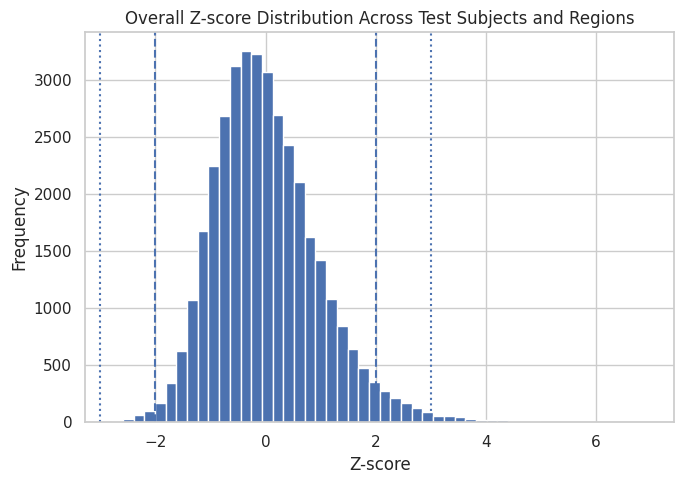

Saved:
out/models/INT_HCPYA_full_BLR_187regions/results/overall_Z_score_distribution_test.png


In [ ]:
# ============================================================
# Plot overall Z-score distribution
# ============================================================

import matplotlib.pyplot as plt

all_z = z_values.to_numpy().flatten()

plt.figure(figsize=(7, 5))
plt.hist(all_z, bins=50)
plt.xlabel("Z-score")
plt.ylabel("Frequency")
plt.title("Overall Z-score Distribution Across Test Subjects and Regions")
plt.axvline(-2, linestyle="--")
plt.axvline(2, linestyle="--")
plt.axvline(-3, linestyle=":")
plt.axvline(3, linestyle=":")
plt.tight_layout()

hist_path = results_dir / "overall_Z_score_distribution_test.png"
plt.savefig(hist_path, dpi=300)
plt.show()

print("Saved:")
print(hist_path)

In [ ]:
# ============================================================
# Check available plot files
# ============================================================

plot_files = sorted(list(plots_dir.glob("*.png")))

print("Number of plot files:", len(plot_files))
print("First 20 plot files:")
for f in plot_files[:20]:
    print(f.name)

Number of plot files: 748
First 20 plot files:
centiles_Region_100_test_harmonized.png
centiles_Region_100_train_harmonized.png
centiles_Region_101_test_harmonized.png
centiles_Region_101_train_harmonized.png
centiles_Region_102_test_harmonized.png
centiles_Region_102_train_harmonized.png
centiles_Region_103_test_harmonized.png
centiles_Region_103_train_harmonized.png
centiles_Region_104_test_harmonized.png
centiles_Region_104_train_harmonized.png
centiles_Region_105_test_harmonized.png
centiles_Region_105_train_harmonized.png
centiles_Region_106_test_harmonized.png
centiles_Region_106_train_harmonized.png
centiles_Region_107_test_harmonized.png
centiles_Region_107_train_harmonized.png
centiles_Region_108_test_harmonized.png
centiles_Region_108_train_harmonized.png
centiles_Region_109_test_harmonized.png
centiles_Region_109_train_harmonized.png


qq_Region_1_test.png


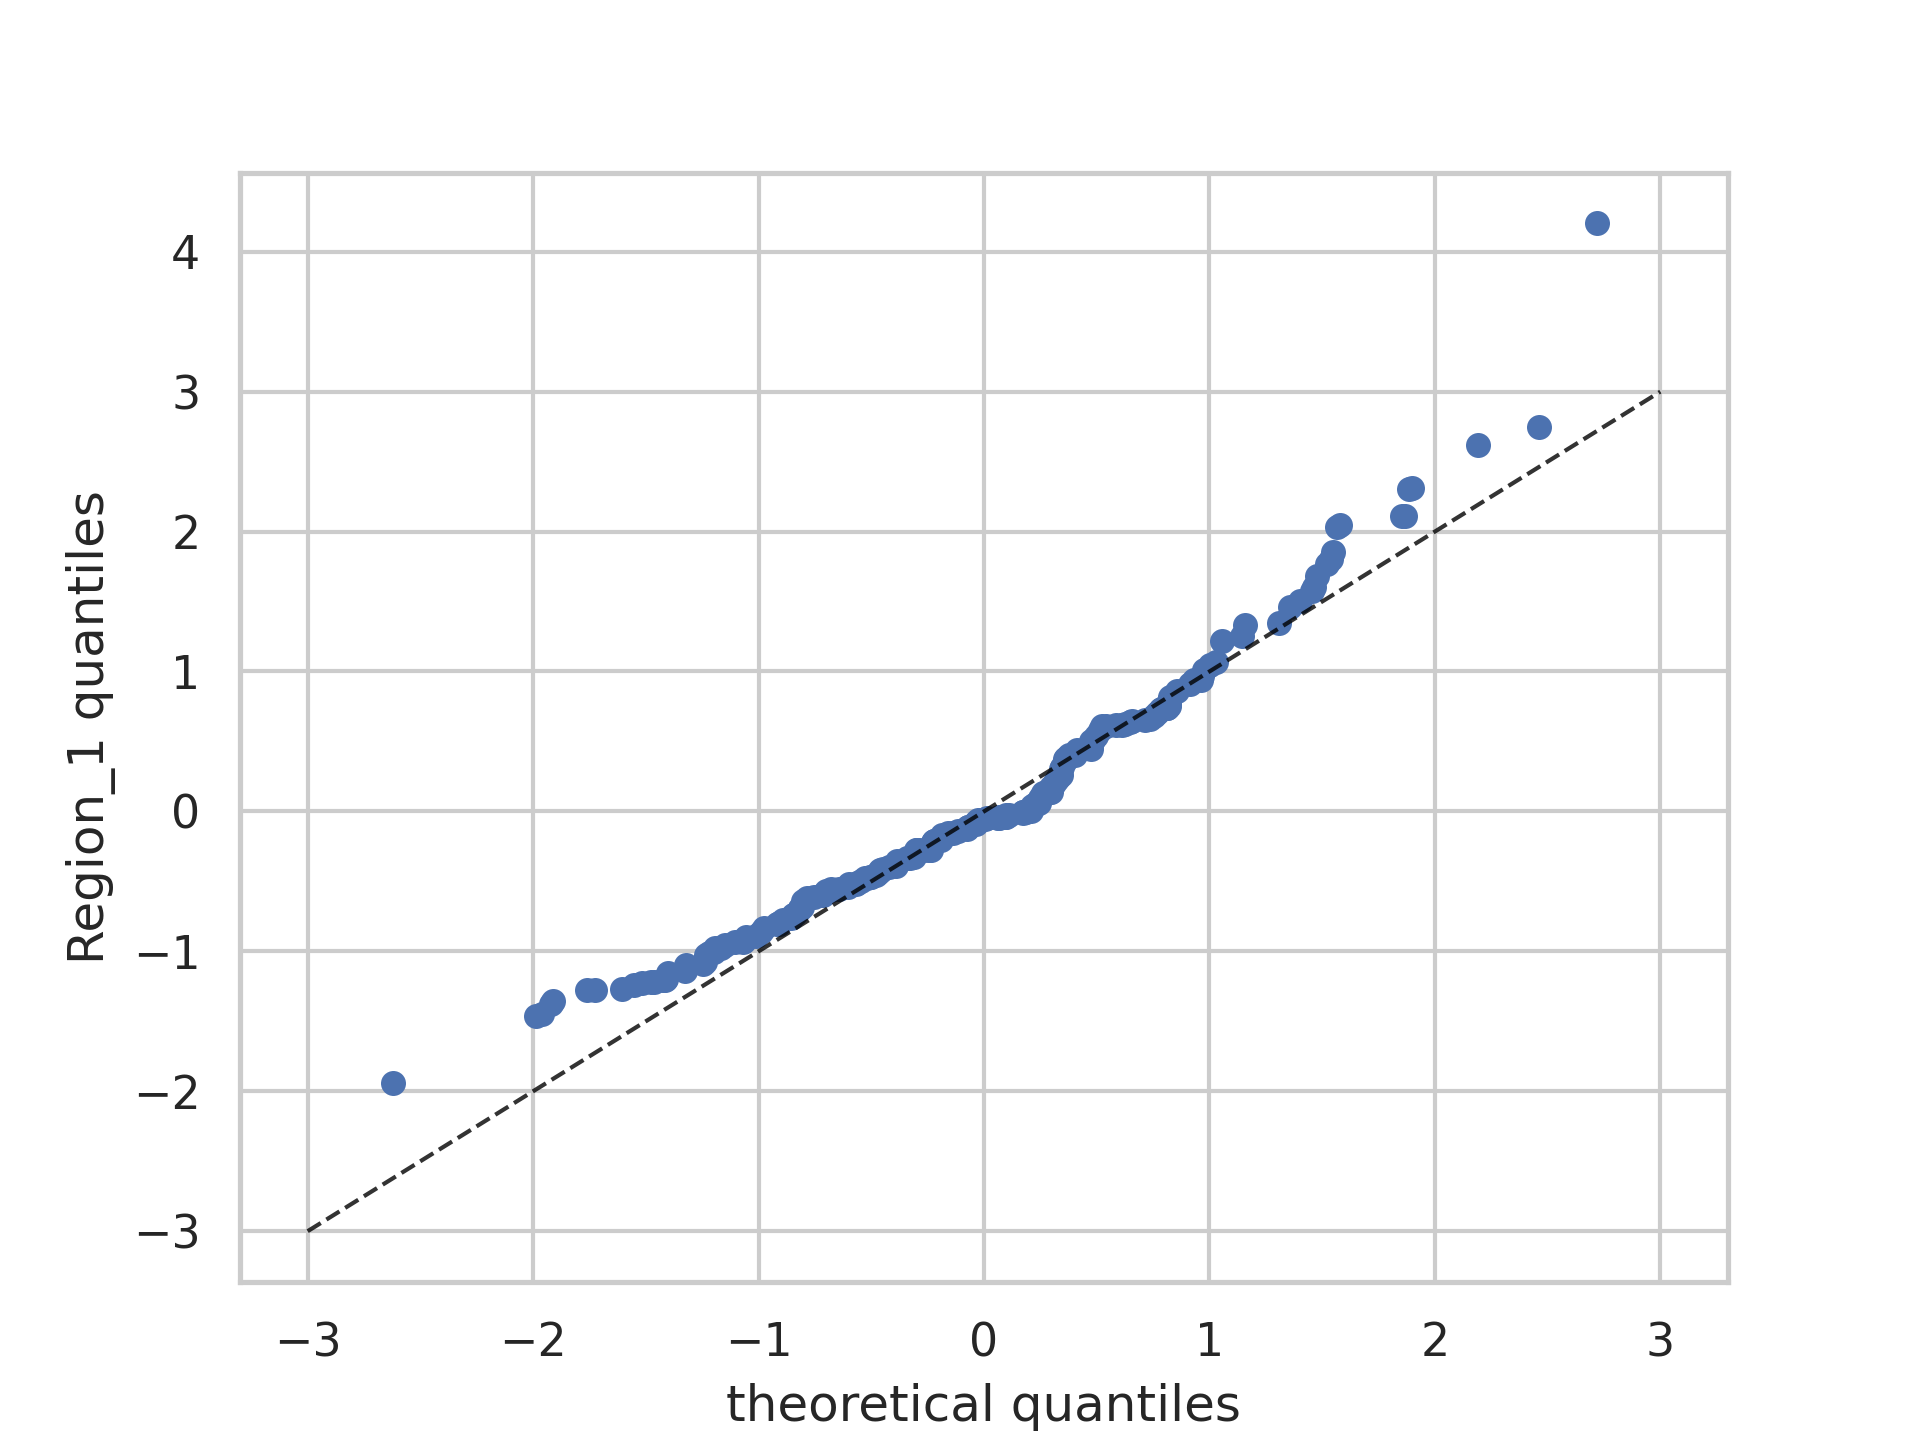

centiles_Region_1_test_harmonized.png


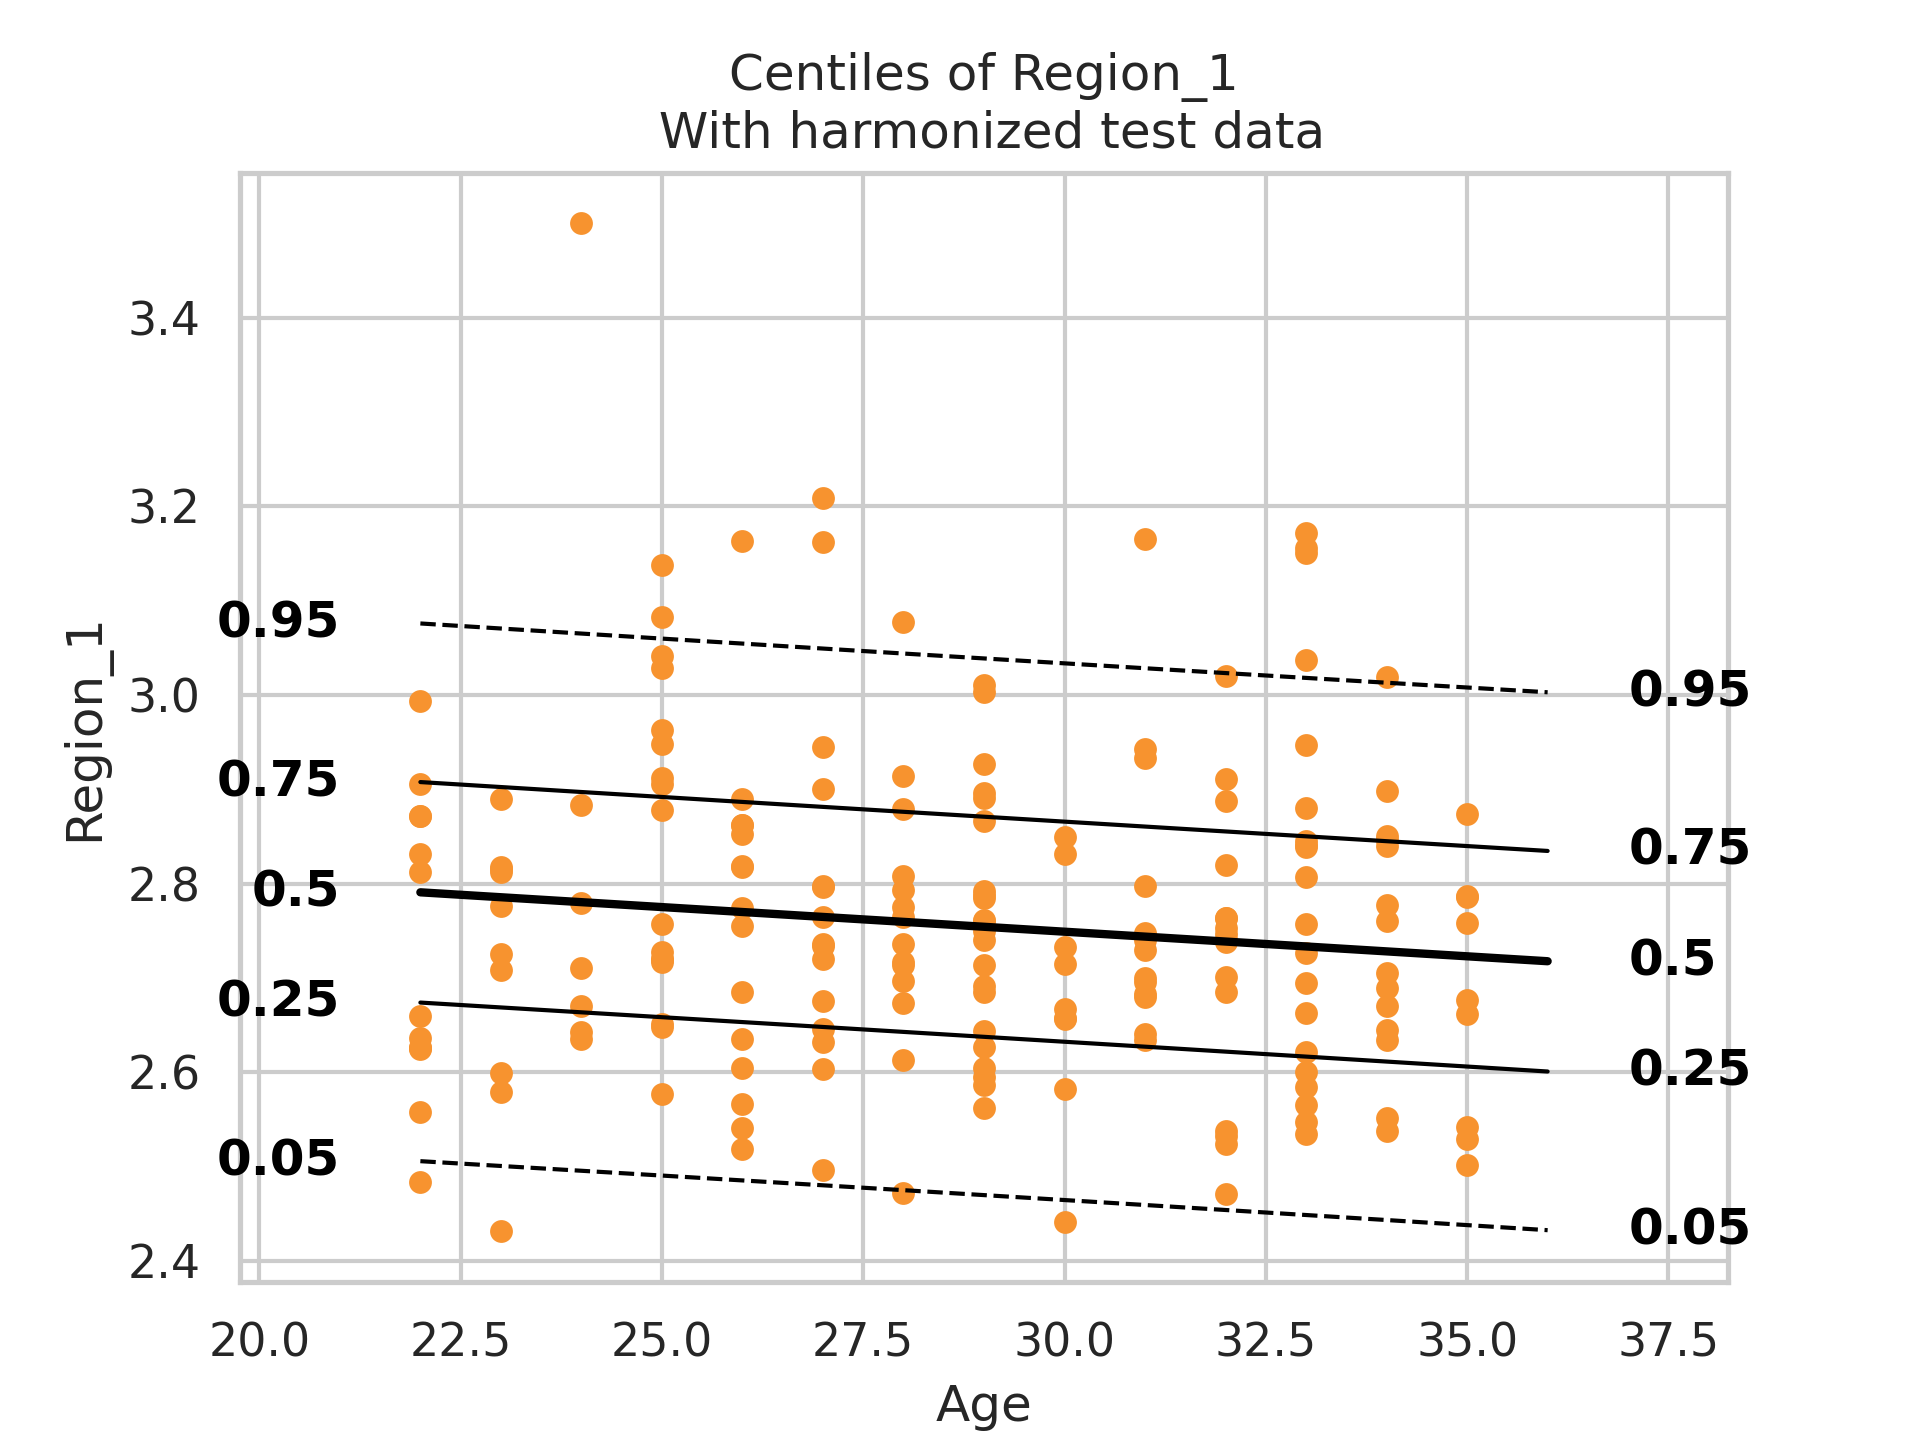

qq_Region_1_train.png


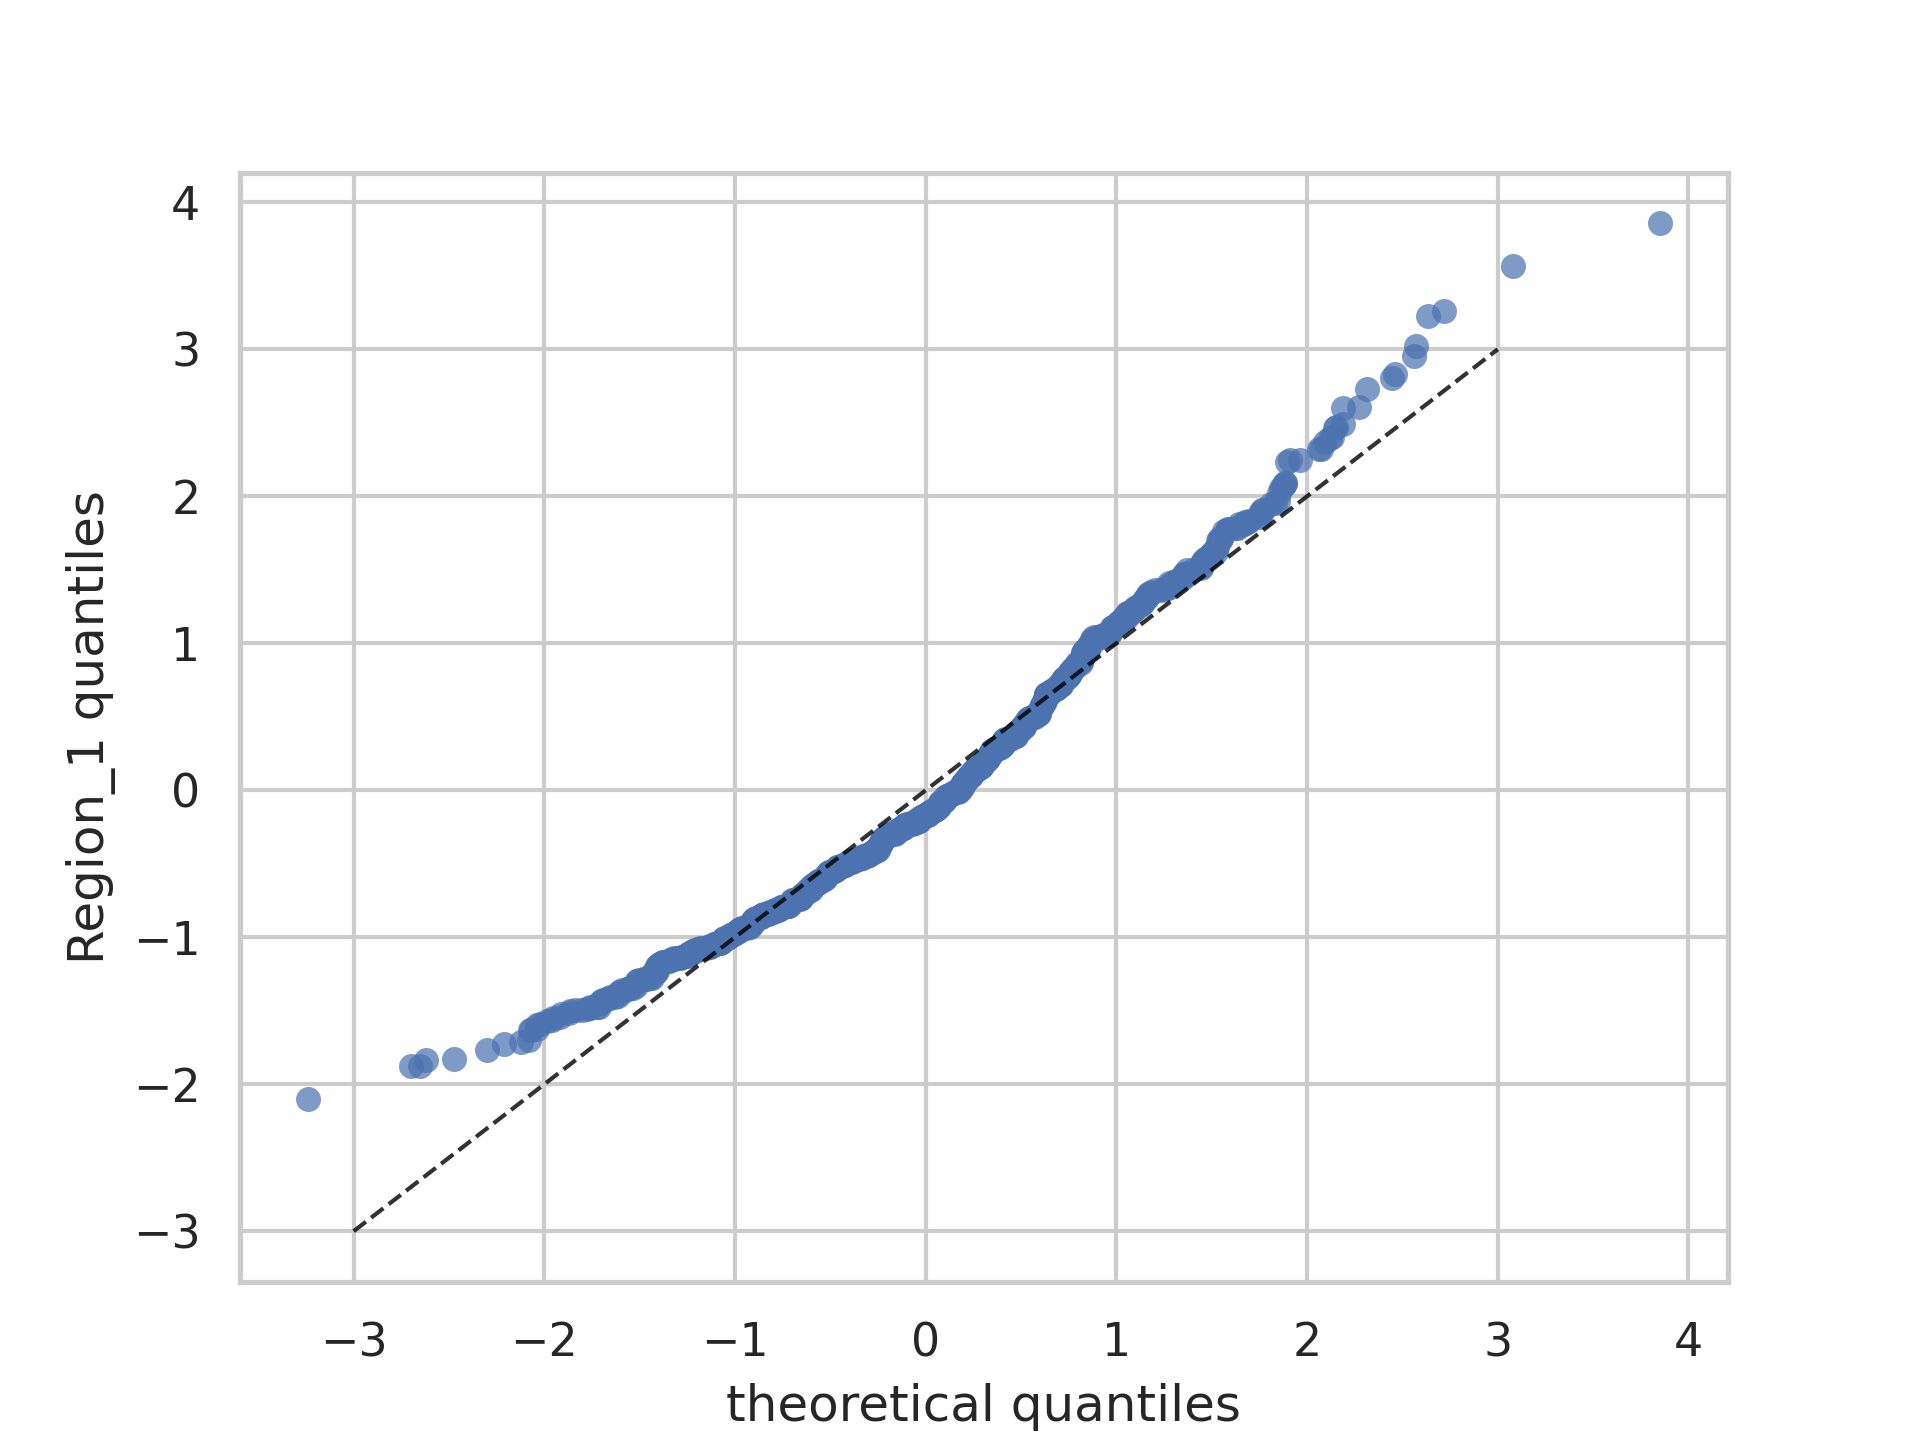

centiles_Region_1_train_harmonized.png


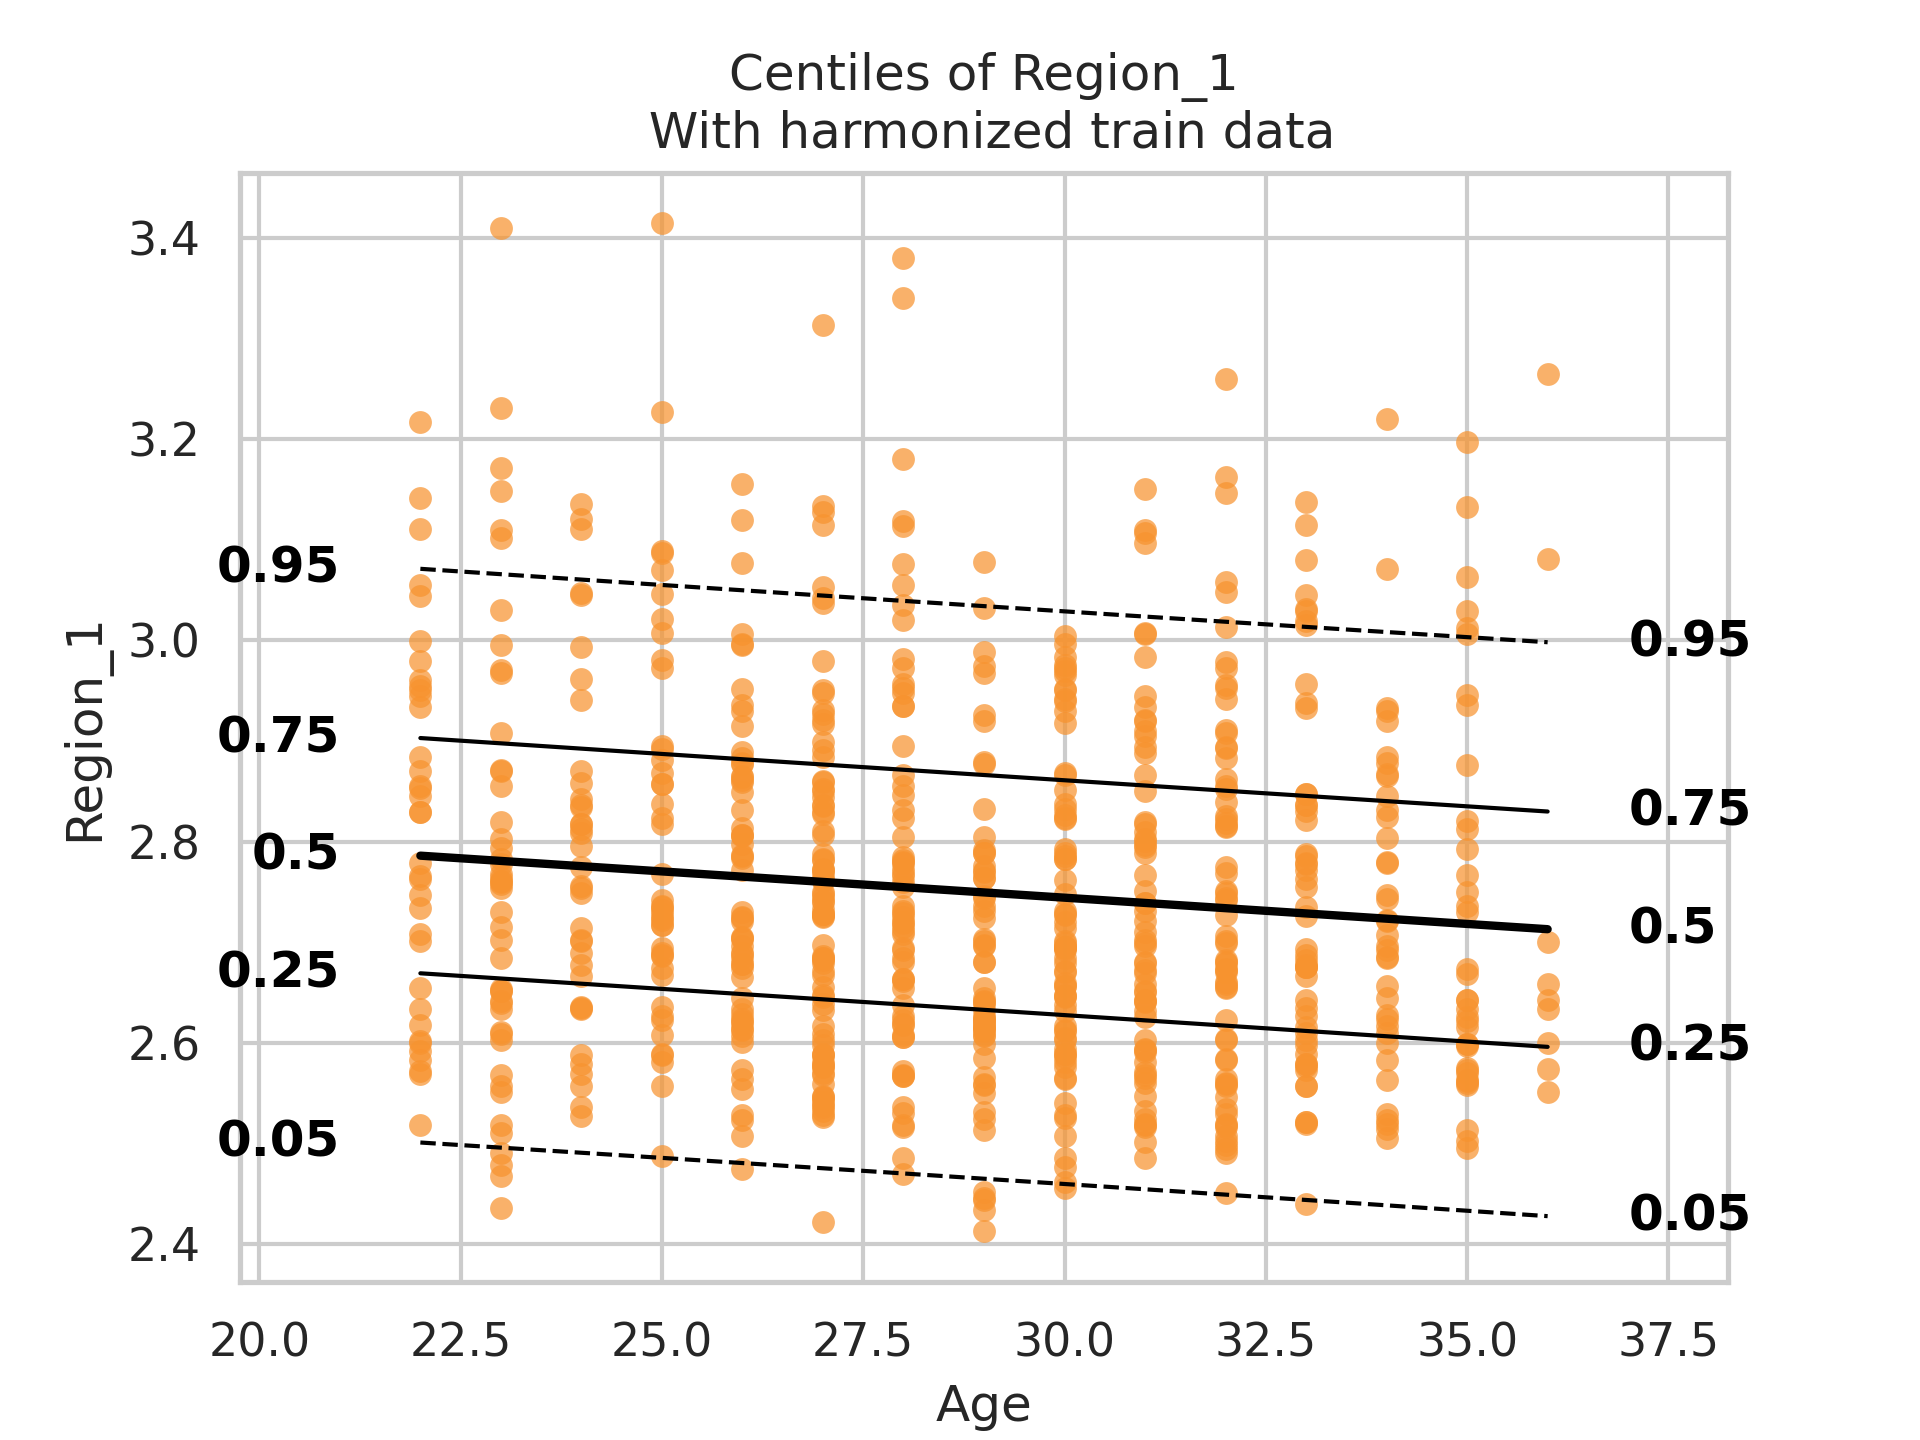

In [ ]:
# ============================================================
# Display representative QQ and centile plots
# ============================================================

from IPython.display import Image, display

region_to_check = "Region_1"

candidate_plots = [
    plots_dir / f"qq_{region_to_check}_test.png",
    plots_dir / f"centiles_{region_to_check}_test_harmonized.png",
    plots_dir / f"qq_{region_to_check}_train.png",
    plots_dir / f"centiles_{region_to_check}_train_harmonized.png"
]

for p in candidate_plots:
    if p.exists():
        print(p.name)
        display(Image(filename=str(p)))
    else:
        print("Missing:", p.name)

Worst MACE region: Region_183
qq_Region_183_test.png


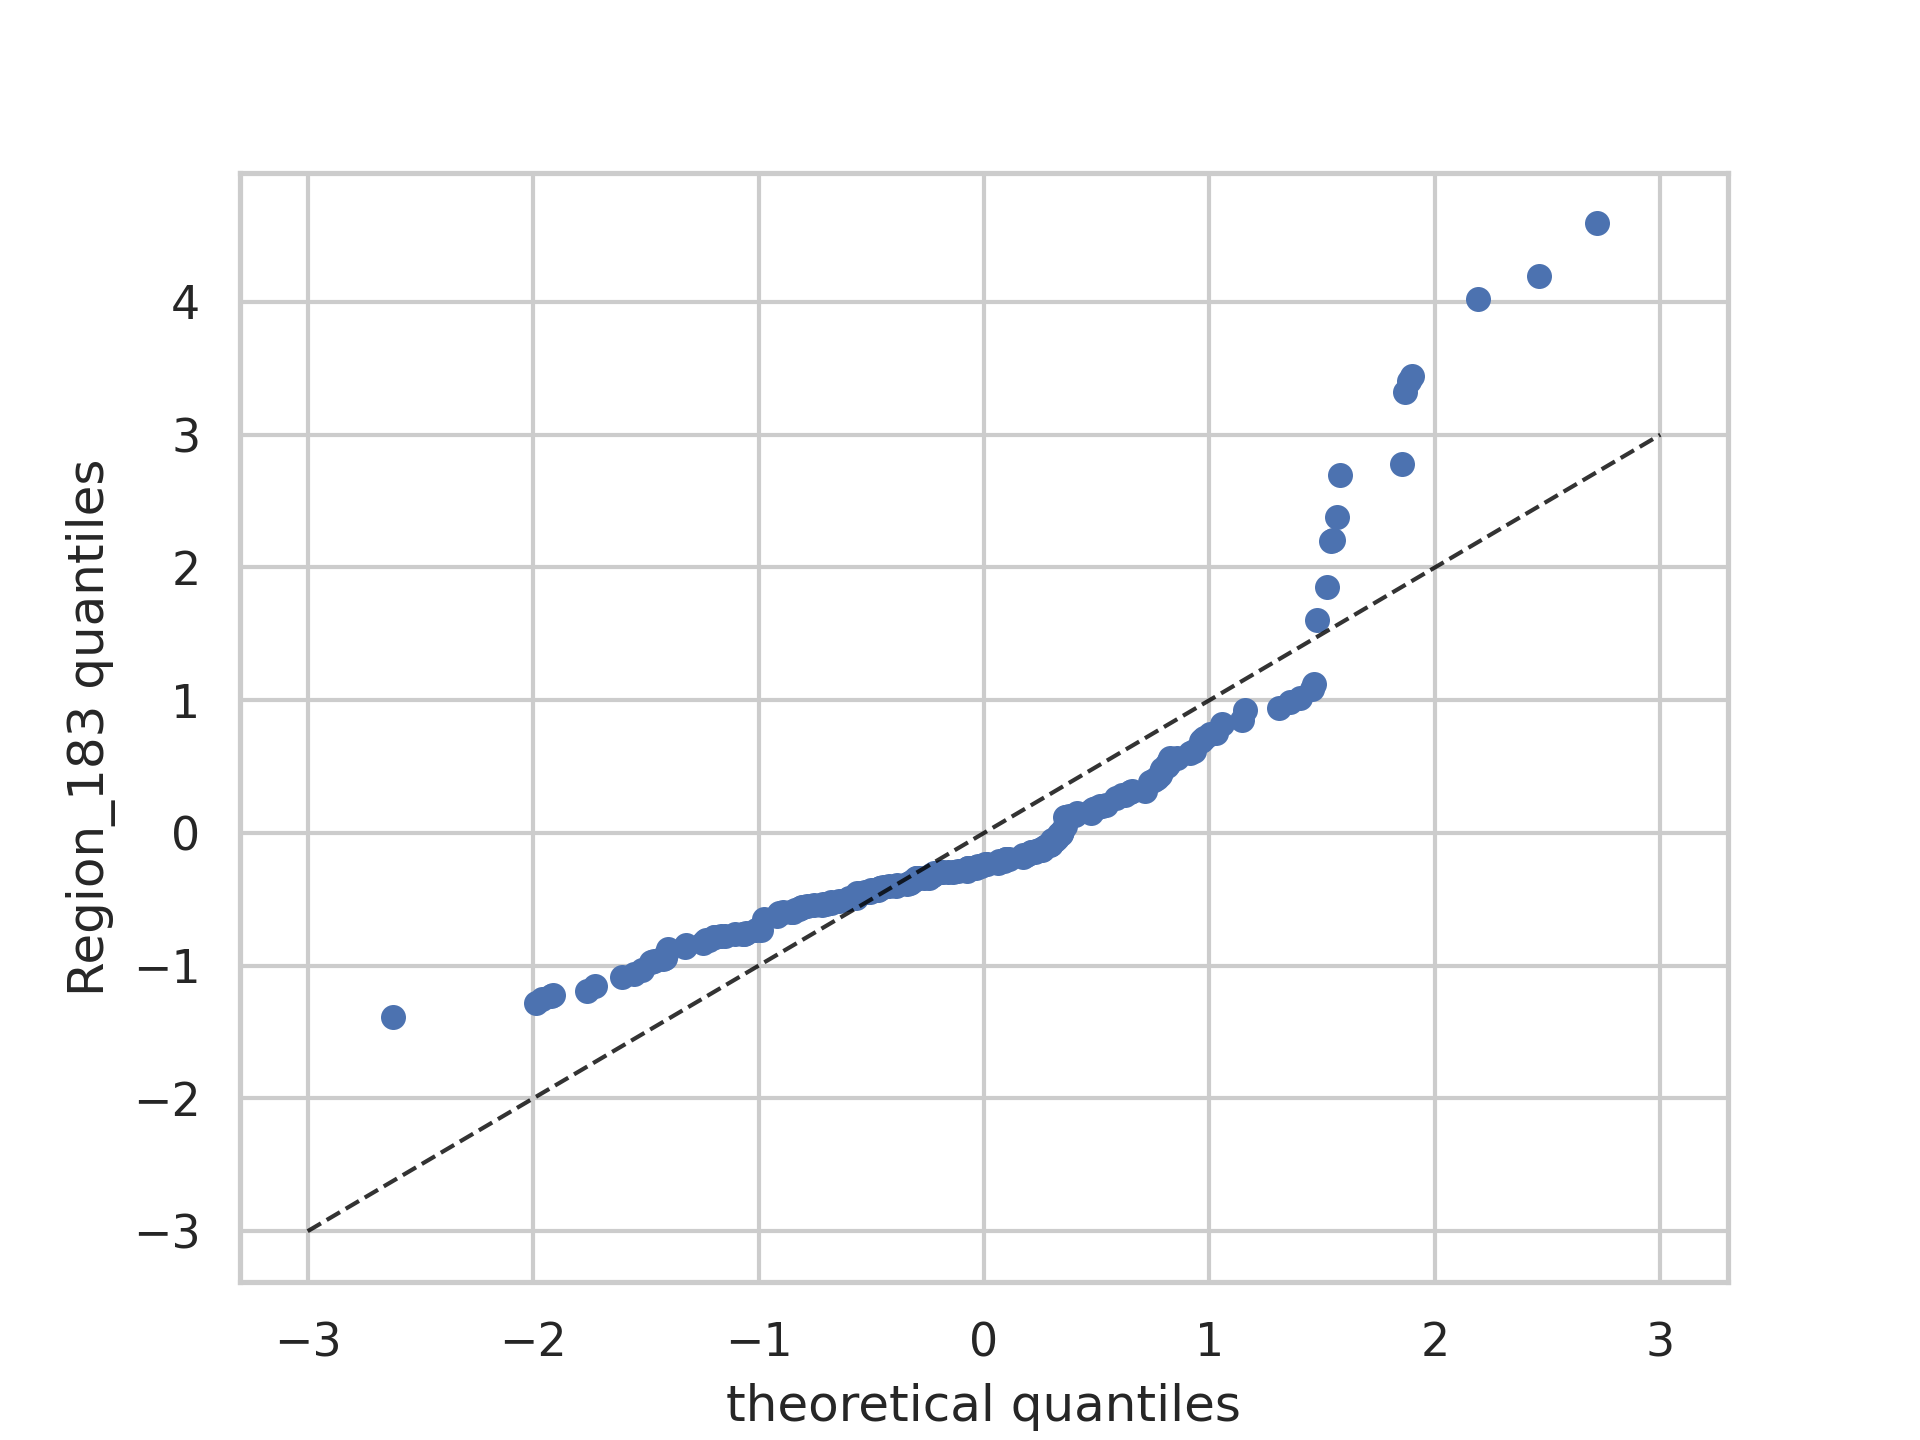

centiles_Region_183_test_harmonized.png


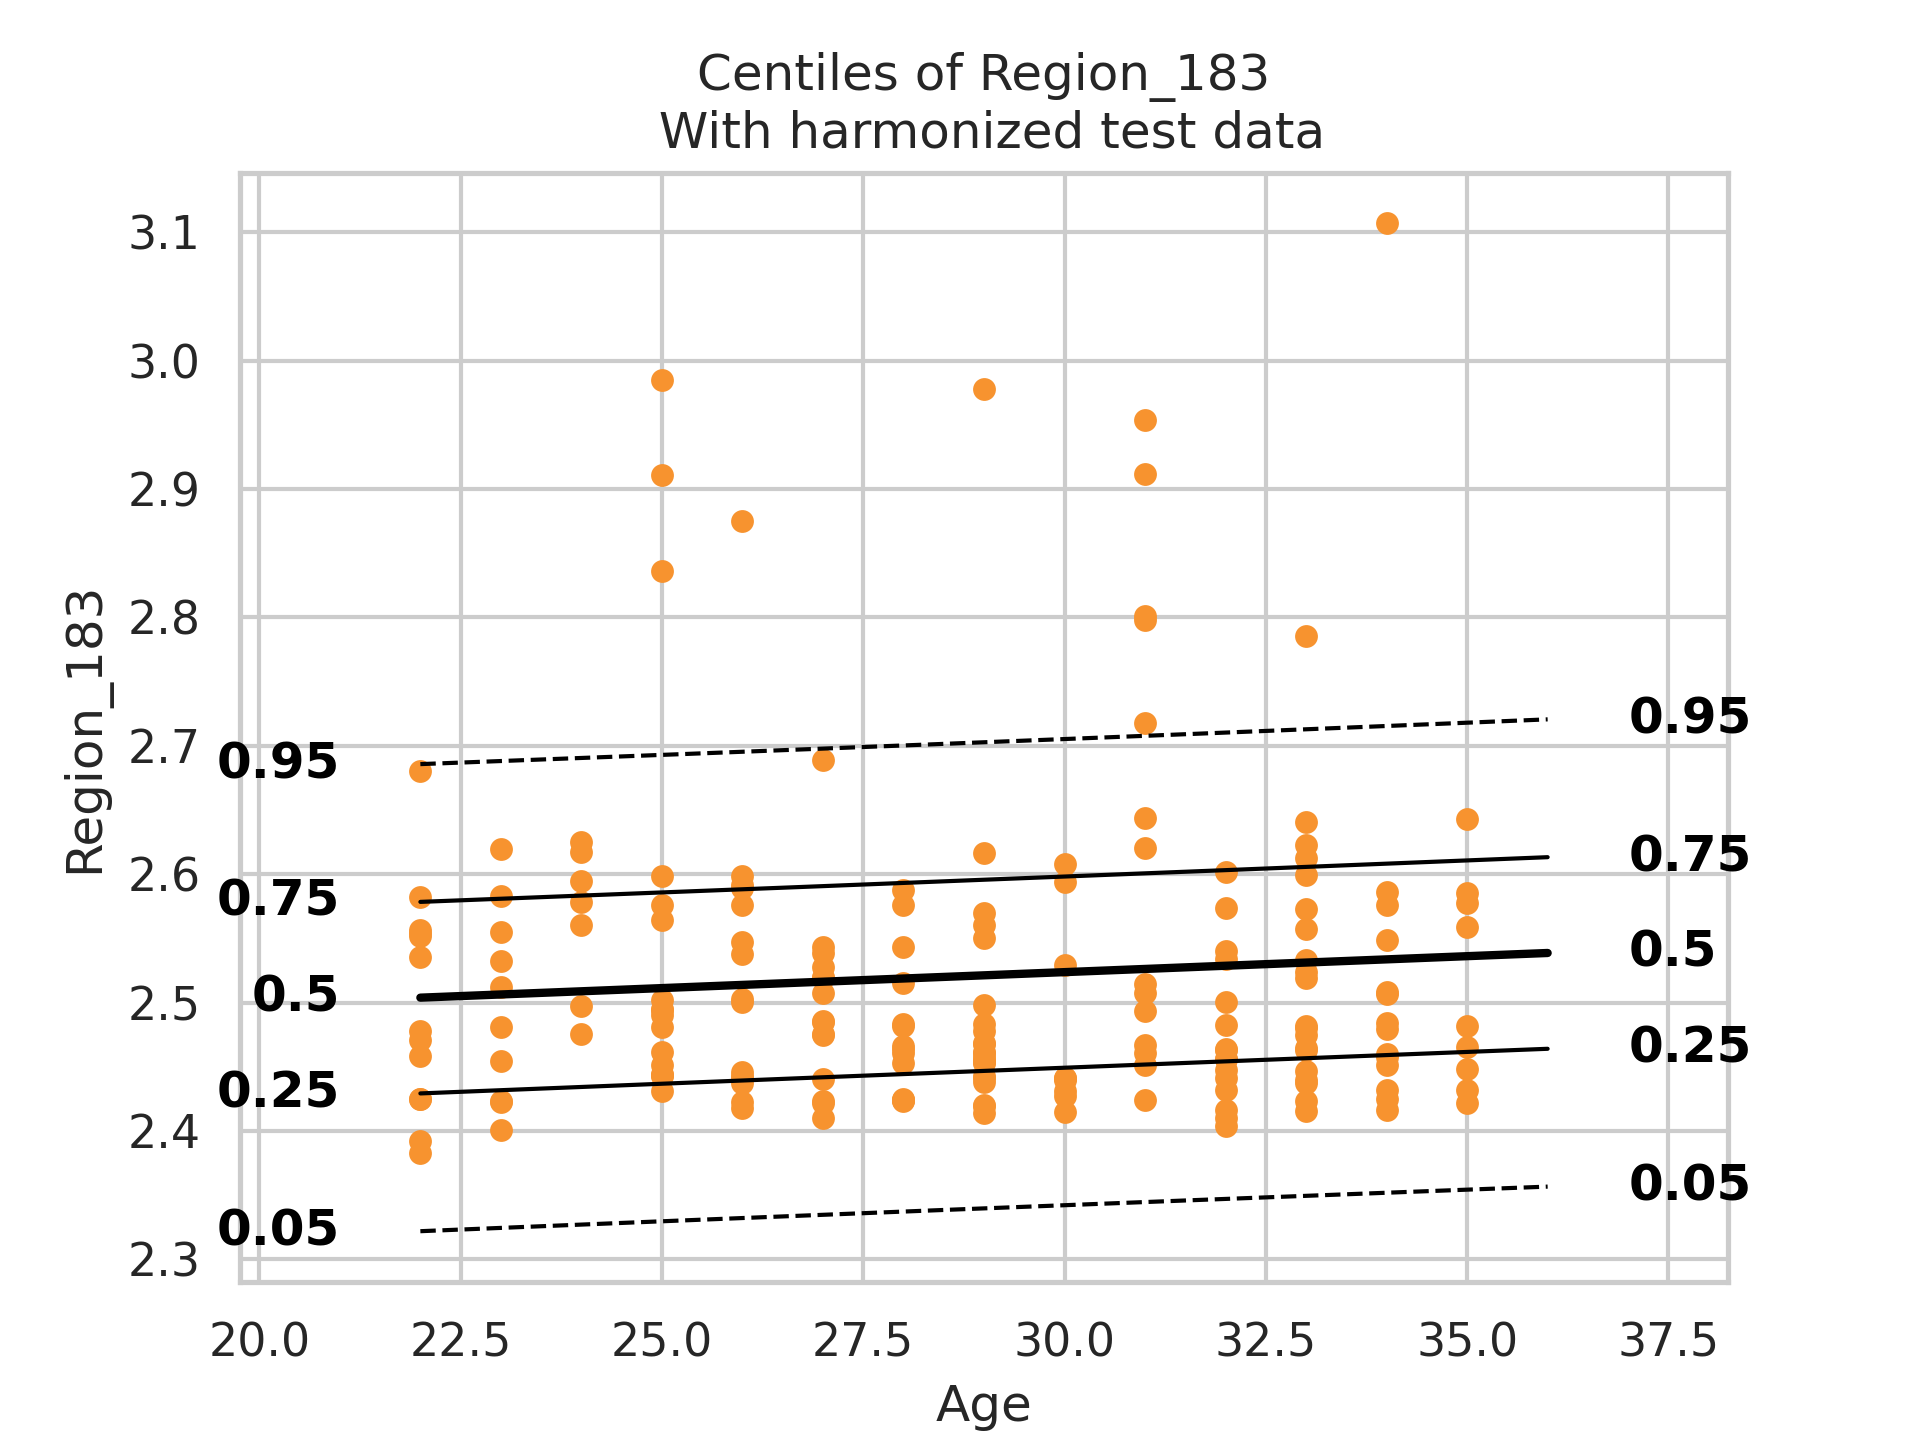

In [ ]:
# ============================================================
# Display plots for the worst MACE region
# ============================================================

if "MACE" in stats_test_t.columns:
    worst_region = stats_test_t["MACE"].idxmax()
    print("Worst MACE region:", worst_region)

    worst_plots = [
        plots_dir / f"qq_{worst_region}_test.png",
        plots_dir / f"centiles_{worst_region}_test_harmonized.png"
    ]

    for p in worst_plots:
        if p.exists():
            print(p.name)
            display(Image(filename=str(p)))
        else:
            print("Missing:", p.name)

In [ ]:
# ============================================================
# STEP 2.5.1 POST-HOC ANALYSIS
# 1. Create analysis-ready Z-score matrix
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

save_dir_blr_full = "./out/models/INT_HCPYA_full_BLR_187regions"
results_dir = Path(save_dir_blr_full) / "results"

z_test = pd.read_csv(results_dir / "Z_test.csv")
stats_test = pd.read_csv(results_dir / "statistics_test.csv")

region_cols = [col for col in z_test.columns if col.startswith("Region_")]

Z = z_test[region_cols].copy()

print("Z-score matrix shape:", Z.shape)
display(Z.head())

Z-score matrix shape: (195, 187)


,Region_1,Region_10,Region_100,Region_101,Region_102,Region_103,Region_104,Region_105,Region_106,Region_107,...,Region_90,Region_91,Region_92,Region_93,Region_94,Region_95,Region_96,Region_97,Region_98,Region_99
0,0.241537,-0.365428,0.026788,-0.109372,-0.075505,0.932424,0.236402,0.635214,-0.574673,-0.277689,...,-1.092715,0.042828,-0.273681,-1.382108,-0.522650,1.759828,-1.039663,0.499947,-0.041931,0.555355
1,-0.329730,-0.033889,-1.226054,-0.852274,-1.018184,-0.470718,-0.470092,-0.421141,-0.237854,-0.501459,...,-0.949356,-0.639178,-0.377722,-0.819421,-0.418357,0.696265,-0.103019,1.536877,0.693473,-0.539156
2,0.611102,0.484023,-0.752392,-0.575008,-0.270988,0.453086,-0.253278,-0.386377,-0.273436,-0.277778,...,0.844837,0.667715,0.166984,-0.164701,0.399511,-0.148080,-0.216738,0.107762,-0.441715,-0.463895
3,0.256140,0.692501,0.453010,0.639428,0.974813,0.423017,0.397849,0.484327,0.343757,-0.078285,...,1.088991,0.526944,-0.045524,-0.388622,-0.157768,0.903968,0.438183,0.563573,0.463386,0.150191
4,-0.214937,-1.033404,-1.139802,-1.060208,-1.225176,-1.231595,-0.953559,-0.942742,-1.463644,-1.093196,...,-1.049295,-0.850495,-1.327714,-1.276919,-1.131988,-0.641600,-0.782452,-0.987225,-1.011323,-1.348590


In [ ]:
# ============================================================
# 2-5.2. Flag low-calibration regions
# ============================================================

stats_test_t = stats_test.set_index("statistic").T

# 기준은 너무 엄격한 exclusion이 아니라 flag 용도
low_calibration_regions = stats_test_t[
    (stats_test_t["MACE"] > 0.06) |
    (stats_test_t["ShapiroW"] < 0.90)
].copy()

print("Number of low-calibration regions:", low_calibration_regions.shape[0])
display(low_calibration_regions.sort_values("MACE", ascending=False))

low_calibration_regions.to_csv(
    results_dir / "low_calibration_regions_flagged.csv"
)

print("Saved:", results_dir / "low_calibration_regions_flagged.csv")

Number of low-calibration regions: 13


statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
Region_183,0.161768,0.089231,0.027027,-0.087540,1.355832,0.161744,0.107174,0.491183,3.087082e-13,0.838256,0.769118
Region_184,0.202689,0.063590,0.015982,-0.108854,1.305986,0.202334,0.056896,0.520758,6.005240e-15,0.797666,0.846057
Region_121,0.082924,0.062564,0.029933,-0.028164,1.277583,0.080845,0.101024,0.364136,1.668117e-07,0.919155,0.919187
Region_36,0.068800,0.062051,0.054509,-0.029129,1.362869,0.063375,0.192730,0.330198,2.426414e-06,0.936625,0.931650
Region_187,0.177889,0.060513,0.012294,-0.088305,1.460586,0.175807,0.048233,0.531915,1.226761e-15,0.824193,0.765010
Region_181,0.218024,0.059487,0.016351,-0.116166,1.312809,0.208467,0.058681,0.551868,6.165208e-17,0.791533,0.891677
Region_164,0.160260,0.058462,0.038919,-0.077273,1.471931,0.159795,0.162478,0.533208,1.016636e-15,0.840205,0.782913
Region_59,0.072732,0.052821,0.027816,-0.029673,1.496869,0.072287,0.104153,0.340612,1.103080e-06,0.927713,0.855369
Region_166,0.179277,0.051282,0.027073,-0.098430,1.341403,0.179250,0.104780,0.503730,6.077638e-14,0.820750,0.859384
Region_58,0.104870,0.049231,0.021542,-0.051379,1.348357,0.100697,0.074544,0.354341,3.731593e-07,0.899303,0.892179


Saved: out/models/INT_HCPYA_full_BLR_187regions/results/low_calibration_regions_flagged.csv


In [ ]:
# ============================================================
# 2.5.3. Create QC-pass Z-score matrix
# ============================================================

low_calibration_region_names = low_calibration_regions.index.tolist()

qc_pass_regions = [
    r for r in region_cols
    if r not in low_calibration_region_names
]

Z_qc = z_test[qc_pass_regions].copy()

print("All regions:", len(region_cols))
print("QC-pass regions:", len(qc_pass_regions))
print("Removed/flagged regions:", len(low_calibration_region_names))

Z_qc.to_csv(results_dir / "Z_test_QC_pass_regions.csv", index=False)

print("Saved:", results_dir / "Z_test_QC_pass_regions.csv")

All regions: 187
QC-pass regions: 174
Removed/flagged regions: 13
Saved: out/models/INT_HCPYA_full_BLR_187regions/results/Z_test_QC_pass_regions.csv


In [ ]:
# ============================================================
# 2.5.4. Subject-level deviation burden with covariates
# ============================================================

subject_deviation = z_test[["observations", "subject_ids"]].copy()

subject_deviation["mean_abs_Z"] = Z.abs().mean(axis=1)
subject_deviation["max_abs_Z"] = Z.abs().max(axis=1)
subject_deviation["n_regions_abs_Z_gt_2"] = (Z.abs() > 2).sum(axis=1)
subject_deviation["n_regions_abs_Z_gt_3"] = (Z.abs() > 3).sum(axis=1)

# Add covariates from df_prep
covariate_info = df_prep.rename(columns={"subject_id": "subject_ids"})[
    ["subject_ids", "Age", "Avg_Mean_FD_included", "Sex"]
]

subject_deviation = subject_deviation.merge(
    covariate_info,
    on="subject_ids",
    how="left"
)

subject_deviation = subject_deviation.sort_values(
    "n_regions_abs_Z_gt_3",
    ascending=False
)

display(subject_deviation.head(20))

subject_deviation.to_csv(
    results_dir / "subject_deviation_burden_with_covariates.csv",
    index=False
)

print("Saved:", results_dir / "subject_deviation_burden_with_covariates.csv")

,observations,subject_ids,mean_abs_Z,max_abs_Z,n_regions_abs_Z_gt_2,n_regions_abs_Z_gt_3,Age,Avg_Mean_FD_included,Sex
112,559,628,2.449223,5.624351,113,52,24,0.108143,M
162,843,936,2.112949,5.077022,101,46,27,0.092259,M
21,109,130,1.323532,6.929067,45,25,34,0.155954,F
38,191,219,1.758869,5.808228,78,25,25,0.128760,M
37,189,217,1.560433,5.820595,58,20,33,0.147687,F
97,487,554,1.782847,4.259531,75,18,25,0.120427,F
20,104,125,1.473082,6.106965,51,13,31,0.102708,F
34,181,207,1.537787,4.848841,57,12,25,0.135043,F
101,497,565,1.325419,5.597044,32,10,29,0.094301,F
79,417,479,1.081258,4.427362,30,9,26,0.110037,M


Saved: out/models/INT_HCPYA_full_BLR_187regions/results/subject_deviation_burden_with_covariates.csv


In [ ]:
# ============================================================
# 2.5.5. Check whether deviation burden is related to motion
# ============================================================

corr_motion_meanZ = subject_deviation["Avg_Mean_FD_included"].corr(
    subject_deviation["mean_abs_Z"]
)

corr_motion_extremeZ = subject_deviation["Avg_Mean_FD_included"].corr(
    subject_deviation["n_regions_abs_Z_gt_3"]
)

print("Correlation: motion vs mean_abs_Z =", corr_motion_meanZ)
print("Correlation: motion vs n_regions_abs_Z_gt_3 =", corr_motion_extremeZ)

Correlation: motion vs mean_abs_Z = 0.11880114833313989
Correlation: motion vs n_regions_abs_Z_gt_3 = 0.047626126876149213


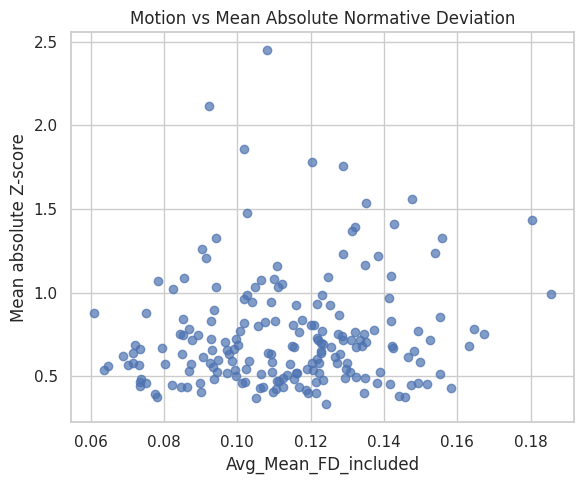

Saved: out/models/INT_HCPYA_full_BLR_187regions/results/motion_vs_mean_abs_Z_test.png


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(
    subject_deviation["Avg_Mean_FD_included"],
    subject_deviation["mean_abs_Z"],
    alpha=0.7
)
plt.xlabel("Avg_Mean_FD_included")
plt.ylabel("Mean absolute Z-score")
plt.title("Motion vs Mean Absolute Normative Deviation")
plt.tight_layout()

motion_plot_path = results_dir / "motion_vs_mean_abs_Z_test.png"
plt.savefig(motion_plot_path, dpi=300)
plt.show()

print("Saved:", motion_plot_path)

In [ ]:
# ============================================================
# 2.5.6. Dimensionality reduction: PCA on Z-scores
# ============================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Use QC-pass regions for sensitivity-safe PCA
Z_for_pca = Z_qc.copy()

# Standardize region-wise Z values before PCA
scaler = StandardScaler()
Z_scaled = scaler.fit_transform(Z_for_pca)

pca = PCA()
Z_pca = pca.fit_transform(Z_scaled)

explained = pca.explained_variance_ratio_

print("Explained variance first 10 PCs:")
print(explained[:10])

# Save PCA scores
pca_scores = pd.DataFrame(
    Z_pca[:, :10],
    columns=[f"PC{i+1}" for i in range(10)]
)

pca_scores.insert(0, "subject_ids", z_test["subject_ids"].values)

pca_scores.to_csv(results_dir / "PCA_scores_test_QC_pass_regions.csv", index=False)

print("Saved:", results_dir / "PCA_scores_test_QC_pass_regions.csv")

Explained variance first 10 PCs:
[0.55554411 0.07247784 0.0605037  0.03360397 0.02916635 0.02342934
 0.01411987 0.01201271 0.01088751 0.00932651]
Saved: out/models/INT_HCPYA_full_BLR_187regions/results/PCA_scores_test_QC_pass_regions.csv


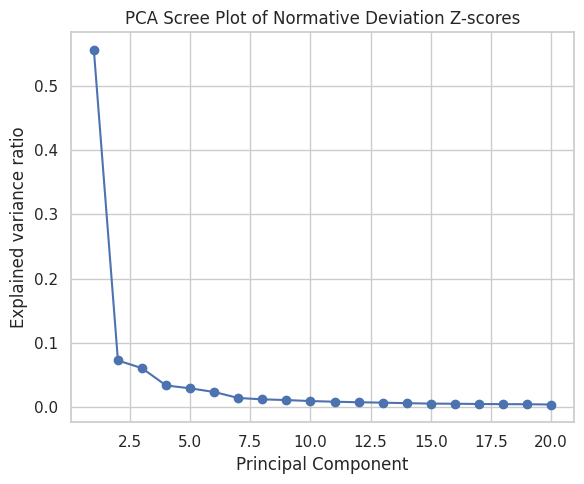

Saved: out/models/INT_HCPYA_full_BLR_187regions/results/PCA_scree_plot_QC_pass_regions.png


In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(np.arange(1, 21), explained[:20], marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained variance ratio")
plt.title("PCA Scree Plot of Normative Deviation Z-scores")
plt.tight_layout()

pca_plot_path = results_dir / "PCA_scree_plot_QC_pass_regions.png"
plt.savefig(pca_plot_path, dpi=300)
plt.show()

print("Saved:", pca_plot_path)

In [ ]:
# ============================================================
# 2.5.7. Clustering on PCA scores
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use first few PCs
X_cluster = pca_scores[[f"PC{i+1}" for i in range(5)]].values

silhouette_results = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_cluster)
    sil = silhouette_score(X_cluster, labels)
    silhouette_results.append({"k": k, "silhouette": sil})

silhouette_df = pd.DataFrame(silhouette_results)

display(silhouette_df)

silhouette_df.to_csv(results_dir / "clustering_silhouette_results.csv", index=False)

print("Saved:", results_dir / "clustering_silhouette_results.csv")

,k,silhouette
0,2,0.365112
1,3,0.305212
2,4,0.263163
3,5,0.210120
4,6,0.207910


Saved: out/models/INT_HCPYA_full_BLR_187regions/results/clustering_silhouette_results.csv


In [ ]:
best_k = silhouette_df.sort_values("silhouette", ascending=False).iloc[0]["k"]
best_k = int(best_k)

print("Best k:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_cluster)

cluster_result = pca_scores[["subject_ids", "PC1", "PC2", "PC3", "PC4", "PC5"]].copy()
cluster_result["cluster"] = cluster_labels

cluster_result = cluster_result.merge(
    subject_deviation,
    on="subject_ids",
    how="left"
)

display(cluster_result.head())

cluster_result.to_csv(results_dir / "cluster_results_test_QC_pass_regions.csv", index=False)

print("Saved:", results_dir / "cluster_results_test_QC_pass_regions.csv")

Best k: 2


,subject_ids,PC1,PC2,PC3,PC4,PC5,cluster,observations,mean_abs_Z,max_abs_Z,n_regions_abs_Z_gt_2,n_regions_abs_Z_gt_3,Age,Avg_Mean_FD_included,Sex
0,5,0.273872,-1.985159,4.811353,-2.265353,-0.230240,0,4,0.580735,2.162073,1,0,35,0.127168,F
1,18,-2.920536,2.297769,5.803346,-1.262534,-2.099028,0,16,0.615964,2.352215,2,0,30,0.090744,M
2,19,-1.801820,0.490491,0.396526,1.488224,0.346930,0,17,0.332231,1.064077,0,0,34,0.124307,M
3,30,5.662185,-3.084309,1.504988,-0.064543,-0.066969,1,28,0.510676,1.767962,0,0,33,0.155253,F
4,40,-10.165709,-2.666387,0.511717,-0.777694,0.646995,0,36,0.714620,1.531962,0,0,22,0.152595,M


Saved: out/models/INT_HCPYA_full_BLR_187regions/results/cluster_results_test_QC_pass_regions.csv


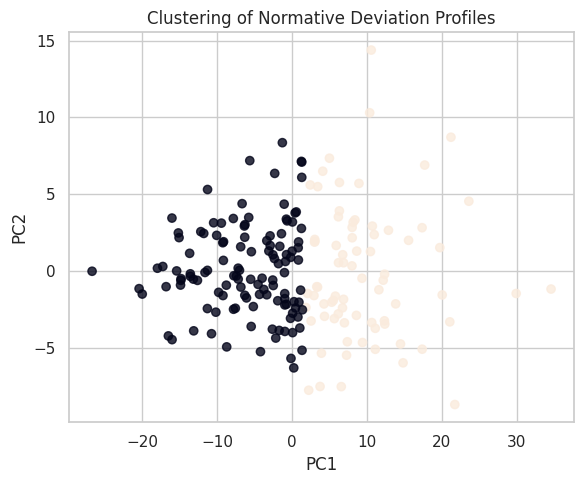

Saved: out/models/INT_HCPYA_full_BLR_187regions/results/PCA_cluster_plot_test_QC_pass_regions.png


In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(
    cluster_result["PC1"],
    cluster_result["PC2"],
    c=cluster_result["cluster"],
    alpha=0.8
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clustering of Normative Deviation Profiles")
plt.tight_layout()

cluster_plot_path = results_dir / "PCA_cluster_plot_test_QC_pass_regions.png"
plt.savefig(cluster_plot_path, dpi=300)
plt.show()

print("Saved:", cluster_plot_path)

In [ ]:
# ============================================================
# 2.5.8
# Summarize cluster characteristics
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

save_dir_blr_full = "./out/models/INT_HCPYA_full_BLR_187regions"
results_dir = Path(save_dir_blr_full) / "results"

cluster_result = pd.read_csv(results_dir / "cluster_results_test_QC_pass_regions.csv")

print("Cluster counts:")
display(cluster_result["cluster"].value_counts().sort_index())

print("\nCluster summary for Age, motion, and deviation burden:")
cluster_summary = cluster_result.groupby("cluster")[
    ["Age", "Avg_Mean_FD_included", "mean_abs_Z", "max_abs_Z",
     "n_regions_abs_Z_gt_2", "n_regions_abs_Z_gt_3", "PC1", "PC2"]
].agg(["mean", "std", "median", "min", "max"])

display(cluster_summary)

cluster_summary.to_csv(results_dir / "cluster_characteristics_summary.csv")

print("Saved:", results_dir / "cluster_characteristics_summary.csv")

Cluster counts:


,count
cluster,
0,120
1,75



Cluster summary for Age, motion, and deviation burden:


Age                          Avg_Mean_FD_included            \
              mean       std median min max                 mean       std   
cluster                                                                      
0        28.591667  3.937529   29.0  22  35             0.112058  0.026380   
1        28.933333  3.658878   29.0  22  35             0.115434  0.020792   

                                       ...       PC1                      \
           median       min       max  ...      mean       std    median   
cluster                                ...                                 
0        0.110658  0.060827  0.185604  ... -6.024943  6.061443 -5.290345   
1        0.118963  0.071470  0.158403  ...  9.639909  6.526288  8.040279   

                                    PC2                                \
               min        max      mean       std    median       min   
cluster                                                                 
0       -26.702477   1.395949  0.069758  2.955660 -0.232825 -6.289333   
1         1.861202  34.612988 -0.111613  4.377584 -1.035860 -8.672555   

                    
               max  
cluster             
0         8.357611  
1        14.381123  

[2 rows x 40 columns]

Saved: out/models/INT_HCPYA_full_BLR_187regions/results/cluster_characteristics_summary.csv


In [ ]:
# ============================================================
# 2.5.9
# Check sex distribution by cluster
# ============================================================

sex_cluster_table = pd.crosstab(
    cluster_result["cluster"],
    cluster_result["Sex"],
    margins=True
)

display(sex_cluster_table)

sex_cluster_table.to_csv(results_dir / "cluster_by_sex_table.csv")

print("Saved:", results_dir / "cluster_by_sex_table.csv")

Sex,F,M,All
cluster,,,
0,70,50,120
1,35,40,75
All,105,90,195


Saved: out/models/INT_HCPYA_full_BLR_187regions/results/cluster_by_sex_table.csv


In [ ]:
# ============================================================
# STEP 2.5.10
# Statistical comparisons between clusters
# ============================================================

from scipy.stats import mannwhitneyu, chi2_contingency

variables_to_test = [
    "Age",
    "Avg_Mean_FD_included",
    "mean_abs_Z",
    "max_abs_Z",
    "n_regions_abs_Z_gt_2",
    "n_regions_abs_Z_gt_3",
    "PC1",
    "PC2"
]

test_results = []

clusters = sorted(cluster_result["cluster"].unique())

for var in variables_to_test:
    group0 = cluster_result.loc[cluster_result["cluster"] == clusters[0], var].dropna()
    group1 = cluster_result.loc[cluster_result["cluster"] == clusters[1], var].dropna()

    stat, p = mannwhitneyu(group0, group1, alternative="two-sided")

    test_results.append({
        "variable": var,
        "cluster0_median": group0.median(),
        "cluster1_median": group1.median(),
        "mannwhitney_U": stat,
        "p_value": p
    })

test_results_df = pd.DataFrame(test_results)

display(test_results_df)

test_results_df.to_csv(results_dir / "cluster_group_comparison_tests.csv", index=False)

print("Saved:", results_dir / "cluster_group_comparison_tests.csv")

# Sex chi-square test
sex_table = pd.crosstab(cluster_result["cluster"], cluster_result["Sex"])
chi2, p, dof, expected = chi2_contingency(sex_table)

print("\nSex distribution chi-square test")
print("chi2:", chi2)
print("p:", p)
print("dof:", dof)

,variable,cluster0_median,cluster1_median,mannwhitney_U,p_value
0,Age,29.000000,29.000000,4306.5,6.135579e-01
1,Avg_Mean_FD_included,0.110658,0.118963,4053.0,2.441961e-01
2,mean_abs_Z,0.600138,0.726119,3046.0,1.500283e-04
3,max_abs_Z,1.944080,2.841893,1473.0,2.932973e-15
4,n_regions_abs_Z_gt_2,0.000000,6.000000,1613.5,7.547606e-15
5,n_regions_abs_Z_gt_3,0.000000,0.000000,2751.5,2.631048e-11
6,PC1,-5.290345,8.040279,0.0,8.372267e-32
7,PC2,-0.232825,-1.035860,4816.0,4.105717e-01


Saved: out/models/INT_HCPYA_full_BLR_187regions/results/cluster_group_comparison_tests.csv

Sex distribution chi-square test
chi2: 2.0801289682539705
p: 0.14922756750132196
dof: 1


In [ ]:
# ============================================================
# STEP 2.5.11
# Cluster-wise mean Z-score profiles
# ============================================================

z_test = pd.read_csv(results_dir / "Z_test.csv")
low_calibration_regions = pd.read_csv(results_dir / "low_calibration_regions_flagged.csv", index_col=0)

region_cols = [col for col in z_test.columns if col.startswith("Region_")]
low_calibration_region_names = low_calibration_regions.index.tolist()

qc_pass_regions = [
    r for r in region_cols
    if r not in low_calibration_region_names
]

z_with_cluster = z_test[["subject_ids"] + qc_pass_regions].merge(
    cluster_result[["subject_ids", "cluster"]],
    on="subject_ids",
    how="left"
)

cluster_mean_z = z_with_cluster.groupby("cluster")[qc_pass_regions].mean()
cluster_median_z = z_with_cluster.groupby("cluster")[qc_pass_regions].median()

display(cluster_mean_z)

cluster_mean_z.to_csv(results_dir / "cluster_mean_Z_profile_QC_pass_regions.csv")
cluster_median_z.to_csv(results_dir / "cluster_median_Z_profile_QC_pass_regions.csv")

print("Saved cluster mean/median Z profiles.")

,Region_1,Region_10,Region_100,Region_101,Region_102,Region_103,Region_104,Region_105,Region_106,Region_107,...,Region_90,Region_91,Region_92,Region_93,Region_94,Region_95,Region_96,Region_97,Region_98,Region_99
cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.435553,-0.560373,-0.526593,-0.444988,-0.434417,-0.370663,-0.393591,-0.382320,-0.437329,-0.484621,...,-0.332455,-0.315408,-0.252331,-0.309686,-0.277756,-0.389229,-0.514078,-0.399623,-0.422725,-0.482137
1,0.781232,0.645010,0.781444,0.690441,0.726546,0.744400,0.745672,0.841885,0.579771,0.850244,...,0.723516,0.677510,0.543822,0.723403,0.662038,0.570426,0.660643,0.620328,0.743457,0.868106


Saved cluster mean/median Z profiles.


In [ ]:
# ============================================================
# STEP 2.5.12
# Identify regions driving cluster differences
# ============================================================

cluster0 = z_with_cluster[z_with_cluster["cluster"] == 0]
cluster1 = z_with_cluster[z_with_cluster["cluster"] == 1]

region_diff_rows = []

for region in qc_pass_regions:
    mean0 = cluster0[region].mean()
    mean1 = cluster1[region].mean()
    diff = mean1 - mean0

    region_diff_rows.append({
        "region": region,
        "cluster0_mean_Z": mean0,
        "cluster1_mean_Z": mean1,
        "cluster1_minus_cluster0": diff,
        "abs_difference": abs(diff)
    })

region_cluster_diff = pd.DataFrame(region_diff_rows)
region_cluster_diff = region_cluster_diff.sort_values("abs_difference", ascending=False)

display(region_cluster_diff.head(20))

region_cluster_diff.to_csv(
    results_dir / "regions_driving_cluster_differences.csv",
    index=False
)

print("Saved:", results_dir / "regions_driving_cluster_differences.csv")

,region,cluster0_mean_Z,cluster1_mean_Z,cluster1_minus_cluster0,abs_difference
128,Region_56,-0.561867,0.894532,1.456399,1.456399
140,Region_69,-0.512374,0.894144,1.406518,1.406518
145,Region_73,-0.539034,0.824949,1.363984,1.363984
114,Region_43,-0.598547,0.761036,1.359583,1.359583
62,Region_157,-0.460581,0.897841,1.358422,1.358422
173,Region_99,-0.482137,0.868106,1.350243,1.350243
27,Region_125,-0.511781,0.836328,1.348109,1.348109
121,Region_5,-0.458299,0.883877,1.342176,1.342176
142,Region_70,-0.514727,0.827008,1.341736,1.341736
79,Region_175,-0.475790,0.860537,1.336328,1.336328


Saved: out/models/INT_HCPYA_full_BLR_187regions/results/regions_driving_cluster_differences.csv


In [ ]:
# ============================================================
# STEP 2.5.13
# Inspect PCA loadings
# ============================================================

# pca and qc_pass_regions should still exist from your previous PCA code.
# If not, rerun the PCA code before this cell.

pc_loading_df = pd.DataFrame(
    pca.components_.T[:, :5],
    index=qc_pass_regions,
    columns=["PC1_loading", "PC2_loading", "PC3_loading", "PC4_loading", "PC5_loading"]
)

pc_loading_df["abs_PC1_loading"] = pc_loading_df["PC1_loading"].abs()
pc1_top_regions = pc_loading_df.sort_values("abs_PC1_loading", ascending=False).head(20)

display(pc1_top_regions)

pc_loading_df.to_csv(results_dir / "PCA_region_loadings_QC_pass_regions.csv")
pc1_top_regions.to_csv(results_dir / "top_PC1_loading_regions.csv")

print("Saved PCA loading files.")

,PC1_loading,PC2_loading,PC3_loading,PC4_loading,PC5_loading,abs_PC1_loading
Region_56,0.087142,-0.013113,-0.045426,0.033819,-0.097181,0.087142
Region_38,0.086865,0.017795,0.021276,-0.054556,-0.051901,0.086865
Region_147,0.086815,-0.009045,0.034942,-0.039289,-0.009891,0.086815
Region_12,0.086776,-0.006338,0.028611,0.042771,-0.127758,0.086776
Region_96,0.086624,-0.007381,0.014122,0.015032,-0.119089,0.086624
Region_37,0.086559,-0.028495,-0.052796,-0.006399,-0.063452,0.086559
Region_73,0.086527,0.034457,0.070571,0.008697,-0.060777,0.086527
Region_27,0.086383,-0.041954,0.002502,-0.048739,-0.005293,0.086383
Region_39,0.085846,-0.046435,-0.061490,0.028022,-0.070843,0.085846
Region_142,0.085787,-0.077921,-0.004826,-0.015406,0.030452,0.085787


Saved PCA loading files.


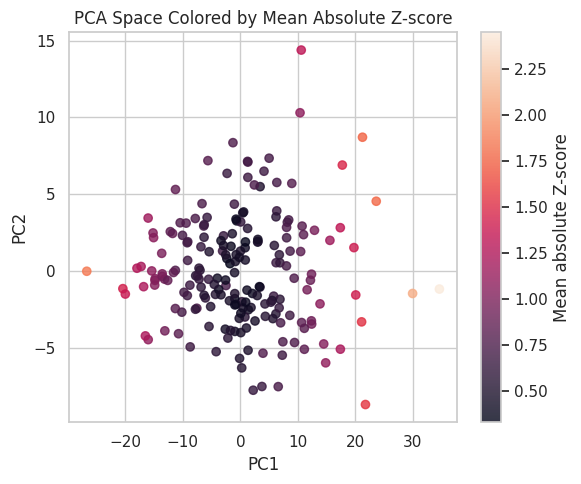

Saved: out/models/INT_HCPYA_full_BLR_187regions/results/PCA_colored_by_mean_abs_Z.png


In [ ]:
# ============================================================
# STEP 2.5.14
# PCA plot colored by deviation burden
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    cluster_result["PC1"],
    cluster_result["PC2"],
    c=cluster_result["mean_abs_Z"],
    alpha=0.8
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Space Colored by Mean Absolute Z-score")
plt.colorbar(scatter, label="Mean absolute Z-score")
plt.tight_layout()

plot_path = results_dir / "PCA_colored_by_mean_abs_Z.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print("Saved:", plot_path)

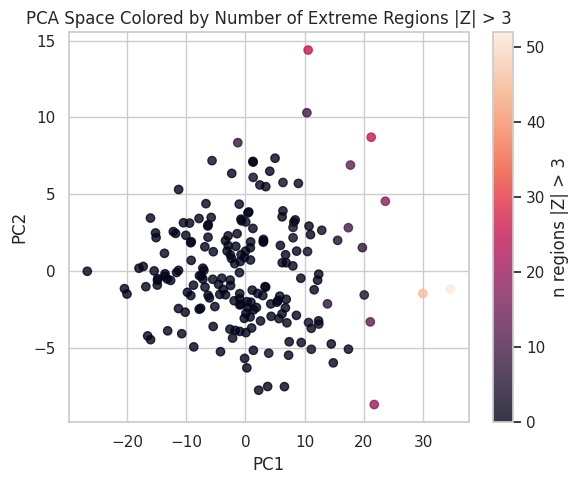

Saved: out/models/INT_HCPYA_full_BLR_187regions/results/PCA_colored_by_extreme_Z_count.png


In [ ]:
plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    cluster_result["PC1"],
    cluster_result["PC2"],
    c=cluster_result["n_regions_abs_Z_gt_3"],
    alpha=0.8
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Space Colored by Number of Extreme Regions |Z| > 3")
plt.colorbar(scatter, label="n regions |Z| > 3")
plt.tight_layout()

plot_path = results_dir / "PCA_colored_by_extreme_Z_count.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print("Saved:", plot_path)

In [ ]:
# ============================================================
# 2.5.15
# Statistical test for region-wise cluster differences
# ============================================================

from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np
from pathlib import Path

save_dir_blr_full = "./out/models/INT_HCPYA_full_BLR_187regions"
results_dir = Path(save_dir_blr_full) / "results"

z_test = pd.read_csv(results_dir / "Z_test.csv")
cluster_result = pd.read_csv(results_dir / "cluster_results_test_QC_pass_regions.csv")
low_calibration_regions = pd.read_csv(
    results_dir / "low_calibration_regions_flagged.csv",
    index_col=0
)

region_cols = [col for col in z_test.columns if col.startswith("Region_")]
low_calibration_region_names = low_calibration_regions.index.tolist()

qc_pass_regions = [
    r for r in region_cols
    if r not in low_calibration_region_names
]

z_with_cluster = z_test[["subject_ids"] + qc_pass_regions].merge(
    cluster_result[["subject_ids", "cluster"]],
    on="subject_ids",
    how="left"
)

rows = []

for region in qc_pass_regions:
    group0 = z_with_cluster.loc[z_with_cluster["cluster"] == 0, region].dropna()
    group1 = z_with_cluster.loc[z_with_cluster["cluster"] == 1, region].dropna()

    stat, p = mannwhitneyu(group0, group1, alternative="two-sided")

    rows.append({
        "region": region,
        "cluster0_mean_Z": group0.mean(),
        "cluster1_mean_Z": group1.mean(),
        "cluster0_median_Z": group0.median(),
        "cluster1_median_Z": group1.median(),
        "cluster1_minus_cluster0": group1.mean() - group0.mean(),
        "abs_difference": abs(group1.mean() - group0.mean()),
        "mannwhitney_U": stat,
        "p_value": p
    })

region_cluster_tests = pd.DataFrame(rows)

# Benjamini-Hochberg FDR correction
region_cluster_tests = region_cluster_tests.sort_values("p_value").reset_index(drop=True)
m = len(region_cluster_tests)
region_cluster_tests["rank"] = np.arange(1, m + 1)
region_cluster_tests["p_fdr_bh"] = region_cluster_tests["p_value"] * m / region_cluster_tests["rank"]
region_cluster_tests["p_fdr_bh"] = region_cluster_tests["p_fdr_bh"].clip(upper=1)

region_cluster_tests = region_cluster_tests.sort_values(
    "abs_difference",
    ascending=False
)

display(region_cluster_tests.head(30))

region_cluster_tests.to_csv(
    results_dir / "regionwise_cluster_difference_tests_FDR.csv",
    index=False
)

print("Saved:", results_dir / "regionwise_cluster_difference_tests_FDR.csv")

,region,cluster0_mean_Z,cluster1_mean_Z,cluster0_median_Z,cluster1_median_Z,cluster1_minus_cluster0,abs_difference,mannwhitney_U,p_value,rank,p_fdr_bh
0,Region_56,-0.561867,0.894532,-0.593433,0.845261,1.456399,1.456399,593.0,2.221650e-24,1,3.865671e-22
5,Region_69,-0.512374,0.894144,-0.519509,0.815618,1.406518,1.406518,764.0,1.977468e-22,6,5.734657e-21
1,Region_73,-0.539034,0.824949,-0.571846,0.715892,1.363984,1.363984,634.0,6.635641e-24,2,5.773008e-22
15,Region_43,-0.598547,0.761036,-0.702126,0.597656,1.359583,1.359583,845.0,1.547633e-21,16,1.683050e-20
9,Region_157,-0.460581,0.897841,-0.513635,0.844519,1.358422,1.358422,796.0,4.481393e-22,10,7.797623e-21
56,Region_99,-0.482137,0.868106,-0.493578,0.723361,1.350243,1.350243,1077.0,4.394073e-19,57,1.341348e-18
18,Region_125,-0.511781,0.836328,-0.522259,0.707188,1.348109,1.348109,856.0,2.039556e-21,19,1.867804e-20
21,Region_5,-0.458299,0.883877,-0.423559,0.854140,1.342176,1.342176,878.0,3.533539e-21,22,2.794708e-20
2,Region_70,-0.514727,0.827008,-0.503218,0.682995,1.341736,1.341736,733.0,8.893093e-23,3,5.157994e-21
22,Region_175,-0.475790,0.860537,-0.532823,0.805469,1.336328,1.336328,887.0,4.420197e-21,23,3.343975e-20


Saved: out/models/INT_HCPYA_full_BLR_187regions/results/regionwise_cluster_difference_tests_FDR.csv


In [ ]:
# ============================================================
# 2.5.16
# Create final cluster interpretation summary
# ============================================================

cluster_summary = pd.read_csv(
    results_dir / "cluster_group_comparison_tests.csv"
)

top_regions = pd.read_csv(
    results_dir / "regions_driving_cluster_differences.csv"
).head(20)

top_pc1 = pd.read_csv(
    results_dir / "top_PC1_loading_regions.csv"
)

final_interpretation = {
    "n_test_subjects": cluster_result.shape[0],
    "n_cluster_0": int((cluster_result["cluster"] == 0).sum()),
    "n_cluster_1": int((cluster_result["cluster"] == 1).sum()),
    "best_k": 2,
    "silhouette_k2": 0.365112,
    "PC1_explained_variance": 0.55554411,
    "PC2_explained_variance": 0.07247784,
    "motion_mean_abs_Z_correlation": 0.11880114833313989,
    "motion_extreme_Z_correlation": 0.047626126876149213,
    "main_interpretation": (
        "Cluster 1 shows higher normative deviation burden than Cluster 0, "
        "with no clear evidence that the cluster difference is driven by age, sex, or motion."
    ),
    "top_cluster_driving_regions": ", ".join(top_regions["region"].head(10).tolist()),
    "top_PC1_loading_regions": ", ".join(top_pc1.iloc[:10, 0].tolist())
}

final_interpretation_df = pd.DataFrame([final_interpretation])

display(final_interpretation_df.T)

final_interpretation_df.to_csv(
    results_dir / "final_posthoc_cluster_interpretation_summary.csv",
    index=False
)

print("Saved:", results_dir / "final_posthoc_cluster_interpretation_summary.csv")

,0
n_test_subjects,195
n_cluster_0,120
n_cluster_1,75
best_k,2
silhouette_k2,0.365112
PC1_explained_variance,0.555544
PC2_explained_variance,0.072478
motion_mean_abs_Z_correlation,0.118801
motion_extreme_Z_correlation,0.047626
main_interpretation,Cluster 1 shows higher normative deviation bur...


Saved: out/models/INT_HCPYA_full_BLR_187regions/results/final_posthoc_cluster_interpretation_summary.csv


In [ ]:
from pathlib import Path
import os

print("Current directory:", os.getcwd())

print("\nFolders under /content/out/models:")
models_dir = Path("/content/out/models")

if models_dir.exists():
    for p in models_dir.iterdir():
        if p.is_dir():
            print(p)
else:
    print("/content/out/models does not exist.")

Current directory: /content

Folders under /content/out/models:
/content/out/models does not exist.


In [ ]:
from pathlib import Path

candidate_dirs = list(Path("/content").rglob("INT_HCPYA_full_BLR_187regions"))

print("Found candidate folders:")
for p in candidate_dirs:
    print(p)

Found candidate folders:


In [ ]:
import pandas as pd
from pathlib import Path

# Use detected path if it exists
candidate_dirs = list(Path("/content").rglob("INT_HCPYA_full_BLR_187regions"))

if len(candidate_dirs) > 0:
    save_dir_blr_full = candidate_dirs[0]
else:
    save_dir_blr_full = Path("/content/out/models/INT_HCPYA_full_BLR_187regions")

results_dir = save_dir_blr_full / "results"

# Create folder if it does not exist
results_dir.mkdir(parents=True, exist_ok=True)

print("Using results directory:", results_dir)
print("Directory exists:", results_dir.exists())

Using results directory: /content/out/models/INT_HCPYA_full_BLR_187regions/results
Directory exists: True


In [ ]:
final_summary = {
    "dataset": "INT HCPYA 4RUNS",
    "n_total_subjects": 973,
    "n_train": 778,
    "n_test": 195,
    "model": "Bayesian Linear Regression normative model",
    "covariates": "Age, Avg_Mean_FD_included",
    "batch_effect": "Sex",
    "response_variables": "187 INT regions",
    "low_calibration_regions_flagged": 13,
    "qc_pass_regions": 174,
    "PC1_explained_variance": 0.555544,
    "PC2_explained_variance": 0.072478,
    "best_cluster_k": 2,
    "silhouette_k2": 0.365112,
    "cluster_0_n": 120,
    "cluster_1_n": 75,
    "motion_mean_abs_Z_correlation": 0.118801,
    "motion_extreme_Z_correlation": 0.047626,
    "main_result": (
        "Cluster 1 showed higher normative deviation burden than Cluster 0, "
        "with no clear evidence that the cluster difference was driven by age, sex, or motion."
    ),
    "top_cluster_driving_regions": (
        "Region_56, Region_69, Region_73, Region_43, Region_157, "
        "Region_99, Region_125, Region_5, Region_70, Region_175"
    ),
    "next_step": (
        "Downstream regression requires an external cognitive, behavioral, "
        "or clinical outcome file."
    )
}

final_summary_df = pd.DataFrame([final_summary])

display(final_summary_df.T)

output_path = results_dir / "final_normative_modeling_summary_no_external_outcome.csv"
final_summary_df.to_csv(output_path, index=False)

print("Saved:", output_path)

,0
dataset,INT HCPYA 4RUNS
n_total_subjects,973
n_train,778
n_test,195
model,Bayesian Linear Regression normative model
covariates,"Age, Avg_Mean_FD_included"
batch_effect,Sex
response_variables,187 INT regions
low_calibration_regions_flagged,13
qc_pass_regions,174


Saved: /content/out/models/INT_HCPYA_full_BLR_187regions/results/final_normative_modeling_summary_no_external_outcome.csv


In [ ]:
# ============================================================
# FINAL STEP
# Save final summary and README because no external outcome file is available
# ============================================================

import pandas as pd
from pathlib import Path

results_dir = Path("/content/out/models/INT_HCPYA_full_BLR_187regions/results")
results_dir.mkdir(parents=True, exist_ok=True)

final_summary = {
    "dataset": "INT HCPYA 4RUNS",
    "n_total_subjects": 973,
    "n_train": 778,
    "n_test": 195,
    "model": "Bayesian Linear Regression normative model",
    "covariates": "Age, Avg_Mean_FD_included",
    "batch_effect": "Sex",
    "response_variables": "187 INT regions",
    "low_calibration_regions_flagged": 13,
    "qc_pass_regions": 174,
    "PC1_explained_variance": 0.555544,
    "PC2_explained_variance": 0.072478,
    "best_cluster_k": 2,
    "silhouette_k2": 0.365112,
    "cluster_0_n": 120,
    "cluster_1_n": 75,
    "motion_mean_abs_Z_correlation": 0.118801,
    "motion_extreme_Z_correlation": 0.047626,
    "main_result": (
        "Cluster 1 showed higher normative deviation burden than Cluster 0, "
        "with no clear evidence that the cluster difference was driven by age, sex, or motion."
    ),
    "top_cluster_driving_regions": (
        "Region_56, Region_69, Region_73, Region_43, Region_157, "
        "Region_99, Region_125, Region_5, Region_70, Region_175"
    ),
    "analysis_status": (
        "Main normative modeling workflow and post-hoc PCA/clustering analysis were completed. "
        "Downstream regression was not performed because no external cognitive, behavioral, "
        "or clinical outcome file was available."
    ),
    "next_step_if_outcome_available": (
        "Merge external outcome variables by subject_id and test whether mean_abs_Z, "
        "extreme deviation burden, PC scores, or cluster membership predict the outcome."
    )
}

final_summary_df = pd.DataFrame([final_summary])

summary_path = results_dir / "final_normative_modeling_summary_no_external_outcome.csv"
final_summary_df.to_csv(summary_path, index=False)

display(final_summary_df.T)

print("Saved summary:", summary_path)

,0
dataset,INT HCPYA 4RUNS
n_total_subjects,973
n_train,778
n_test,195
model,Bayesian Linear Regression normative model
covariates,"Age, Avg_Mean_FD_included"
batch_effect,Sex
response_variables,187 INT regions
low_calibration_regions_flagged,13
qc_pass_regions,174


Saved summary: /content/out/models/INT_HCPYA_full_BLR_187regions/results/final_normative_modeling_summary_no_external_outcome.csv


In [ ]:
# ============================================================
# Save README text file
# ============================================================

readme_text = """
INT HCPYA Normative Modeling Analysis Summary

This analysis followed the main workflow of the updated normative modeling protocol.

Completed steps:
1. Data Selection
   - Dataset: INT HCPYA 4RUNS
   - N = 973 subjects
   - Response variables: Region_1 to Region_187
   - Covariates: Age, Avg_Mean_FD_included
   - Batch effect: Sex

2. Data Preparation
   - Missing values: 0
   - Extreme outliers using |Z| > 10 check: 0
   - NormData object created
   - Train/test split: 778 train, 195 test

3. Modelling
   - HBR was tested but not used as final model because of divergence issues.
   - Full BLR normative model was used for 187 INT regions.

4. Evaluation
   - Z-score outputs, statistics, QQ plots, and centile plots were generated during the completed analysis.
   - 13 low-calibration regions were flagged.
   - 174 QC-pass regions were retained for post-hoc analysis.

5. Post-hoc Analysis
   - PCA was performed on QC-pass Z-score regions.
   - PC1 explained approximately 55.55% of variance.
   - K-means clustering suggested k = 2.
   - Cluster 1 showed higher normative deviation burden than Cluster 0.
   - Cluster differences were not clearly driven by age, sex, or motion.

Analysis stopped here because no external cognitive, behavioral, or clinical outcome file was available.
The next step, if an outcome file becomes available, is downstream regression.
"""

readme_path = results_dir / "README_analysis_summary_no_external_outcome.txt"

with open(readme_path, "w") as f:
    f.write(readme_text)

print("Saved README:", readme_path)

Saved README: /content/out/models/INT_HCPYA_full_BLR_187regions/results/README_analysis_summary_no_external_outcome.txt


In [ ]:
# ============================================================
# Zip final summary files and download
# ============================================================

import shutil
from pathlib import Path
from google.colab import files
import zipfile

output_folder = Path("/content/out/models/INT_HCPYA_full_BLR_187regions")
zip_path = "/content/INT_HCPYA_final_summary_no_external_outcome"

shutil.make_archive(zip_path, "zip", output_folder)

zip_file = zip_path + ".zip"

with zipfile.ZipFile(zip_file, "r") as z:
    print("Files inside zip:")
    for name in z.namelist():
        print(name)

files.download(zip_file)

Files inside zip:
results/
results/final_normative_modeling_summary_no_external_outcome.csv
results/README_analysis_summary_no_external_outcome.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>